# Case

**Objetivo:** Análise exploratória e de correlação dos dados de campanhas de marketing da Omie, com foco em performance de canais, eficiência do funil de aquisição e alocação de verba.

**Contexto de negócio:** O departamento de Growth precisa gerar crescimento de 10% em NMRR (New Monthly Recurring Revenue) até dez/2023, com orçamento limitado.

**Etapas do funil (topo -> fundo):**
Impressões -> Cliques -> Sessões -> Formulários Enviados -> Lead -> Atribuído -> Agendamentos -> Conquistados -> Apps Pagos

**Período dos dados:** Janeiro a Dezembro de 2022

---
## 1. Importação de Bibliotecas



In [1]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns

# Requisições HTTP - API de câmbio do BCB
import requests

# Testes estatísticos para correlação
from scipy import stats

# Tratamento de encoding em nomes de campanha
from urllib.parse import unquote

# Utilitários
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_style('whitegrid')
sns.set_palette('tab10')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## 2. Carregamento dos Dados



In [2]:
# Carregar os dados
df_campaigns = pd.read_csv('docs/campaigns.csv')
df_data = pd.read_csv('docs/data.csv')

# Verificar o que foi carregado
print(f'campaigns: {df_campaigns.shape[0]} linhas x {df_campaigns.shape[1]} colunas')
print(f'data:      {df_data.shape[0]} linhas x {df_data.shape[1]} colunas')

print(f'\nColunas campaigns: {list(df_campaigns.columns)}')
print(f'Colunas data:      {list(df_data.columns)}')


campaigns: 815 linhas x 4 colunas
data:      233141 linhas x 4 colunas

Colunas campaigns: ['campanha', 'tipo_campanha', 'canal', 'grupo']
Colunas data:      ['data', 'campanha', 'metrica', 'valor']


---
## 3. Auditoria Inicial das Bases

**O que está sendo feito:**
- Diagnóstico inicial de estrutura, tipos, volume e qualidade dos dados recebidos.

**Por que isso importa:**
- Evita que inconsistências de origem contaminem métricas e conclusões posteriores.


In [3]:
# Objetivo: Auditar a tabela de campanhas para validar estrutura, cobertura e qualidade dos campos.
# Leitura prática: Confirma se o dicionário de campanhas está consistente antes dos joins e análises posteriores.

# Auditoria: campaigns
print('=' * 60)
print('CAMPAIGNS')
print('=' * 60)

print(f'\nShape: {df_campaigns.shape[0]} linhas x {df_campaigns.shape[1]} colunas')
print(f'\nTipos de dados:\n{df_campaigns.dtypes}')
print(f'\nValores nulos:\n{df_campaigns.isnull().sum()}')
print(f'\nLinhas duplicadas: {df_campaigns.duplicated().sum()}')

print(f'\nValores únicos por coluna:')
for col in df_campaigns.columns:
    print(f'  {col}: {df_campaigns[col].nunique()}')

print(f'\nCanais: {sorted(df_campaigns["canal"].unique())}')
print(f'\nGrupos: {sorted(df_campaigns["grupo"].unique())}')


CAMPAIGNS

Shape: 815 linhas x 4 colunas

Tipos de dados:
campanha         str
tipo_campanha    str
canal            str
grupo            str
dtype: object

Valores nulos:
campanha         4
tipo_campanha    0
canal            0
grupo            0
dtype: int64

Linhas duplicadas: 6

Valores únicos por coluna:
  campanha: 808
  tipo_campanha: 42
  canal: 14
  grupo: 4

Canais: ['Afiliados', 'CRM', 'Criteo', 'Direto', 'Google Ads', 'Kwai Ads', 'LinkedIn Ads', 'Meta Ads', 'Microsoft Advertising', 'Referral', 'Seedtag', 'Taboola', 'TikTok Ads', 'Weach']

Grupos: ['CRM', 'Direto', 'Pago', 'Referral']


In [4]:
# Objetivo: Auditar a base transacional para mapear qualidade, distribuição e presença de métricas.
# Leitura prática: Garante que a matéria prima do funil está íntegra antes do tratamento analítico.

# Auditoria: data
print('=' * 60)
print('DATA')
print('=' * 60)

print(f'\nShape: {df_data.shape[0]} linhas x {df_data.shape[1]} colunas')
print(f'\nTipos de dados:\n{df_data.dtypes}')
print(f'\nValores nulos:\n{df_data.isnull().sum()}')
print(f'\nLinhas duplicadas: {df_data.duplicated().sum()}')

print(f'\nLinhas totalmente vazias: {df_data.isnull().all(axis=1).sum()}')

print(f'\nMétricas disponiveis: {sorted(df_data["metrica"].dropna().unique())}')
print(f'\nDistribuição de métricas:')
print(df_data['metrica'].value_counts())


DATA

Shape: 233141 linhas x 4 colunas

Tipos de dados:
data        str
campanha    str
metrica     str
valor       str
dtype: object

Valores nulos:
data        13615
campanha    13980
metrica     13615
valor       13615
dtype: int64

Linhas duplicadas: 13614

Linhas totalmente vazias: 13615

Métricas disponiveis: ['agendamento', 'apps_pagos', 'atribuidos', 'clicks', 'faturamento', 'formulario_enviado', 'impressoes', 'investimentos', 'lead', 'sessoes', 'vendas']

Distribuição de métricas:
metrica
sessoes               48661
formulario_enviado    45994
lead                  31792
atribuidos            24881
agendamento           18945
vendas                18240
apps_pagos            14295
faturamento           14226
investimentos          1090
clicks                  701
impressoes              701
Name: count, dtype: int64


### 3.1 Qualidade do JOIN entre tabelas

**O que está sendo feito:** Diagnóstico de cobertura entre as tabelas de campanhas e dados, identificando registros órfãos.

**Por que isso importa:** Registros sem correspondência comprometem a análise de canal e tipo de campanha, gerando pontos cegos na atribuição.


In [5]:
# Objetivo: Medir a cobertura do join entre dicionário de campanhas e base de dados operacional.
# Leitura prática: Quantifica campanhas órfãs e o impacto potencial na confiabilidade das leituras.

# Diagnóstico de join: compara campanhas cadastradas vs campanhas presentes nos dados,
# identifica campanhas órfãs e mede o volume de registros afetados.
def diagnosticar_join(df_camps, df_dados):
    """Calcula e exibe cobertura do join. Retorna set de campanhas órfãs."""
    cadastradas = set(df_camps['campanha'].dropna().unique())
    nos_dados = set(df_dados['campanha'].dropna().unique())
    orfas = nos_dados - cadastradas
    n_orfaos = df_dados[df_dados['campanha'].isin(orfas)].shape[0]

    print(f"Campanhas no dicionário: {len(cadastradas)}")
    print(f"Campanhas nos dados:     {len(nos_dados)}")
    print(f"Match (em ambas):        {len(cadastradas & nos_dados)}")
    print(f"Só no dicionário:        {len(cadastradas - nos_dados)}")
    print(f"Só nos dados (órfãs):    {len(orfas)}")
    print(f"\nRegistros órfãos: {n_orfaos} ({n_orfaos / len(df_dados) * 100:.1f}% da base)")

    return orfas

campanhas_orfas = diagnosticar_join(df_campaigns, df_data)


Campanhas no dicionário: 808
Campanhas nos dados:     805
Match (em ambas):        449
Só no dicionário:        359
Só nos dados (órfãs):    356

Registros órfãos: 76221 (32.7% da base)


---
## 4. Limpeza, Padronização e Enriquecimento

Pipeline de remoção de registros inválidos, conversão de tipos, mapeamento de campanhas órfãs e padronização de nomes.

### 4.1 Remoção de linhas vazias e duplicatas

In [6]:

# Fluxo da etapa: contabiliza base original, remove linhas vazias/duplicadas e
# valida o impacto da limpeza no volume final de registros.
n_bruto = len(df_data)
n_vazias = int(df_data.isnull().all(axis=1).sum())
n_dupl_camps = int(df_campaigns.duplicated().sum())

# Limpar: remover linhas totalmente vazias e depois duplicatas
df_data = df_data.dropna(how='all').drop_duplicates().reset_index(drop=True)
df_campaigns = df_campaigns.drop_duplicates().reset_index(drop=True)

print(f'df_data:      {n_bruto:,} → {len(df_data):,} (removidas {n_bruto - len(df_data):,}  - {n_vazias:,} vazias + restante duplicadas)')
print(f'df_campaigns: removidas {n_dupl_camps} duplicadas → {len(df_campaigns):,} linhas')

df_data:      233,141 → 219,526 (removidas 13,615  - 13,615 vazias + restante duplicadas)
df_campaigns: removidas 6 duplicadas → 809 linhas


### 4.2 Parsing de datas e tipos

**O que está sendo feito:**
- Conversão da coluna de data para datetime e criação de chaves temporais auxiliares (ano_mes, mes, nome_mes).

**Por que isso importa:**
- Garante que agregações por período e gráficos de sazonalidade funcionem corretamente.

In [7]:

# Parsing temporal: converte 'data' para datetime, cria chaves auxiliares
# (ano_mes, mes, nome_mes) e valida cobertura/calendário após conversão.
df_data['data'] = pd.to_datetime(df_data['data'], format='%m/%d/%Y')

# Colunas auxiliares para facilitar agregações temporais
df_data['ano_mes'] = df_data['data'].dt.to_period('M')
df_data['mes'] = df_data['data'].dt.month
df_data['nome_mes'] = df_data['data'].dt.strftime('%b')

# Validação do range de datas
print(f"Range de datas: {df_data['data'].min().date()} a {df_data['data'].max().date()}")
print(f"Dias únicos: {df_data['data'].dt.date.nunique()}")
print(f"Meses: {sorted(df_data['mes'].unique().tolist())}")
print(f"\nTipos após conversão:\n{df_data.dtypes}")

Range de datas: 2022-01-01 a 2022-12-31
Dias únicos: 365
Meses: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Tipos após conversão:
data        datetime64[us]
campanha               str
metrica                str
valor                  str
ano_mes          period[M]
mes                  int32
nome_mes               str
dtype: object


### 4.3 Parsing do investimento (EUR)

**O que está sendo feito:**
- Conversão de valores de investimento do formato europeu (virgula decimal, ponto de milhar) para float.

**Por que isso importa:**
- Sem essa conversão, cálculos de CPA, CPL e ROI retornariam valores incorretos.

In [8]:
# Converte strings para float
# Investimentos vêm no formato europeu "€ 8,50" (vírgula = decimal)
# Demais métricas são inteiros simples como "5500"

# Regra de parsing: normaliza símbolo de moeda e separadores do formato europeu
# (milhar com ponto, decimal com vírgula); valores inválidos retornam NaN.
def parse_valor(val):
    """Converte string de valor para float.
    Trata formato EUR ('€ 8,50') e números simples ('5500').
    """
    if pd.isna(val) or str(val).strip() == '':
        return np.nan
    
    val = str(val).replace('€', '').replace('\u20ac', '').strip()
    
    # Formato europeu: ponto = milhar, vírgula = decimal (ex: "1.234,56")
    if ',' in val and '.' in val:
        val = val.replace('.', '').replace(',', '.')
    elif ',' in val:
        val = val.replace(',', '.')
    
    try:
        return float(val)
    except ValueError:
        return np.nan

# Aplica o parsing linha a linha para padronizar a coluna numérica 'valor_num'.
df_data['valor_num'] = df_data['valor'].apply(parse_valor)

# Validação: investimentos devem ter sido convertidos corretamente
inv = df_data[df_data['metrica'] == 'investimentos']
print(f"Investimentos: {len(inv)} registros")
print(f"  Soma EUR:  {inv['valor_num'].sum():,.2f}")
print(f"  Min:       {inv['valor_num'].min():,.2f}")
print(f"  Max:       {inv['valor_num'].max():,.2f}")
print(f"  Nulos:     {inv['valor_num'].isna().sum()}")
print(f"\nvalor_num nulos total: {df_data['valor_num'].isna().sum()}")

Investimentos: 1090 registros
  Soma EUR:  107,573.70
  Min:       0.00
  Max:       5,566.10
  Nulos:     0

valor_num nulos total: 0


### 4.4 Mapeamento de campanhas órfãs

**O que está sendo feito:**
- Classificação de campanhas presentes nos dados mas ausentes no dicionário, usando heurísticas de nome.

**Por que isso importa:**
- Sem esse mapeamento, 32,7% dos registros ficariam sem canal/grupo, distorcendo todas as análises por canal.

In [9]:

# Classifica cada campanha órfã por heurísticas de nome para inferir
# tipo_campanha, canal e grupo antes do merge com o dicionário.
def classificar_campanha_orfa(nome):
    """Infere canal, grupo e tipo_campanha pelo padrão do nome da campanha."""
    if pd.isna(nome):
        return pd.Series({'tipo_campanha': 'Desconhecido', 'canal': 'Direto', 'grupo': 'Direto'})
    
    nome_decoded = unquote(str(nome)).upper()
    
    # CRM  - padrão: CRM_pme_*
    if nome.startswith('CRM_') or 'CRM_PME' in nome_decoded:
        canal, grupo = 'CRM', 'CRM'
        if 'ABANDONO' in nome_decoded:
            tipo = 'CRM Abandono'
        elif 'CHURN' in nome_decoded:
            tipo = 'CRM Churn'
        elif 'CHATBOT' in nome_decoded:
            tipo = 'CRM Chatbot'
        else:
            tipo = 'CRM Aquisição'
        return pd.Series({'tipo_campanha': tipo, 'canal': canal, 'grupo': grupo})
    
    # Meta Ads  - padrão: contém "facebook" ou "meta"
    if 'FACEBOOK' in nome_decoded or 'META' in nome_decoded:
        return pd.Series({
            'tipo_campanha': 'Facebook Conversão Aquisição',
            'canal': 'Meta Ads', 'grupo': 'Pago'
        })
    
    # Google PMax  - padrão: contém "pmax" ou "performance_max"
    if 'PMAX' in nome_decoded or 'PERFORMANCE_MAX' in nome_decoded:
        return pd.Series({
            'tipo_campanha': 'Google PMax Aquisição',
            'canal': 'Google Ads', 'grupo': 'Pago'
        })
    
    # Referral  - padrão: contém "blog" ou "parceiro"
    if 'BLOG' in nome_decoded or 'PARCEIRO' in nome_decoded:
        return pd.Series({
            'tipo_campanha': 'Blog', 'canal': 'Referral', 'grupo': 'Referral'
        })
    
    # Default: Direto
    return pd.Series({'tipo_campanha': 'Direto', 'canal': 'Direto', 'grupo': 'Direto'})

# Aplicar classificação nas campanhas órfãs (excluir possível header "campanha")
orfas = sorted(campanhas_orfas - {'campanha'})
df_orfas = pd.DataFrame({'campanha': orfas})
df_orfas[['tipo_campanha', 'canal', 'grupo']] = df_orfas['campanha'].apply(classificar_campanha_orfa)

print(f"Campanhas órfãs classificadas: {len(df_orfas)}")
print(f"\nDistribuição por canal:")
print(df_orfas['canal'].value_counts().to_string())

# Concatenar ao dicionário de campanhas
df_campaigns = pd.concat([df_campaigns, df_orfas], ignore_index=True)
df_campaigns = df_campaigns.drop_duplicates(subset='campanha').reset_index(drop=True)

# Revalidar cobertura do join
print(f"\n--- Após mapeamento ---")
diagnosticar_join(df_campaigns, df_data)

Campanhas órfãs classificadas: 356

Distribuição por canal:
canal
CRM           330
Meta Ads       22
Direto          2
Referral        1
Google Ads      1

--- Após mapeamento ---
Campanhas no dicionário: 1164
Campanhas nos dados:     805
Match (em ambas):        805
Só no dicionário:        359
Só nos dados (órfãs):    0

Registros órfãos: 0 (0.0% da base)


set()

### 4.5 Padronização de encoding nos tipos de campanha

**O que está sendo feito:**
- Decodificação de URL encoding e correção de typos nos nomes de tipo de campanha.

**Por que isso importa:**
- Nomes inconsistentes fragmentam a agregação e geram tipos duplicados nas análises.

In [10]:
# Objetivo da célula: normalizar texto (URL encoding), corrigir typos de nomenclatura
# e tratar valores corrompidos antes das validações finais de distribuição.
# Problemas encontrados: URL encoding (%C3%A7 = ç), typos e variações de nome

# 1. Decodificar URL encoding em colunas de texto
for col in ['campanha', 'tipo_campanha']:
    df_campaigns[col] = df_campaigns[col].apply(
        lambda x: unquote(str(x)) if pd.notna(x) else x
    )

# 2. Corrigir typos e padronizar nomes
substituicoes = {
    'Google Dsiplay Aquisição': 'Google Display Aquisição',
    'Google Dsiplay Remarketing': 'Google Display Remarketing',
    'Google Pmax Aquisição': 'Google PMax Aquisição',
    'Google Search Brand Aquisição': 'Google Search Branded Aquisição',
    'Google Search Non Brand Aquisição': 'Google Search Non Branded Aquisição',
    'Bing Search Brand Aquisição': 'Bing Search Branded Aquisição',
    'Bing Search Brand Remarketing': 'Bing Search Branded Remarketing',
}
df_campaigns['tipo_campanha'] = df_campaigns['tipo_campanha'].replace(substituicoes)

# 3. Corrigir valor corrompido (Excel converteu número longo em notação científica)
mask_corrupto = df_campaigns['tipo_campanha'].str.contains('38527E', na=False)
if mask_corrupto.any():
    df_campaigns.loc[mask_corrupto, ['tipo_campanha', 'canal', 'grupo']] = ['Direto', 'Direto', 'Direto']
    print(f"Registros corrompidos corrigidos: {mask_corrupto.sum()}")

# Validação
print(f"\nTipos de campanha únicos: {df_campaigns['tipo_campanha'].nunique()}")
print(f"\nDistribuição de tipo_campanha:")
print(df_campaigns['tipo_campanha'].value_counts().to_string())


Tipos de campanha únicos: 36

Distribuição de tipo_campanha:
tipo_campanha
CRM Aquisição                          276
CRM Abandono                           256
Facebook Conversão Aquisição           140
CRM Churn                              131
Google Search Geral Aquisição          107
Google Search Non Branded Aquisição     34
Google PMax Aquisição                   33
Google Search Branded Aquisição         22
Facebook Conversão Remarketing          22
Google Display Remarketing              21
Blog                                    20
Bing Search Non Branded Aquisição       14
Google Search Geral Remarketing         13
Bing Search Branded Aquisição           12
Bing Search Geral Aquisição              9
Direto                                   8
Facebook WhatsApp Aquisição              6
Google Display Aquisição                 5
Google Discovery Aquisição               5
Google YouTube Aquisição                 4
Bing Search Geral Remarketing            4
Bing Display Remarket

---
## 5. Conversão Cambial EUR -> BRL via API

Conversão dos investimentos de EUR para BRL usando cotações diárias PTAX do Banco Central.

### 5.1 Identificar datas com investimento

In [11]:

# Isola apenas registros de investimentos e extrai as datas únicas com investimento
# para definir o calendário efetivo usado na etapa de câmbio.
df_investimentos = df_data[df_data['metrica'] == 'investimentos'].copy()

datas_investimento = sorted(df_investimentos['data'].dt.date.unique())
print(f"Registros de investimento: {len(df_investimentos)}")
print(f"Datas únicas com investimento: {len(datas_investimento)}")
print(f"Período: {datas_investimento[0]} a {datas_investimento[-1]}")

Registros de investimento: 1090
Datas únicas com investimento: 344
Período: 2022-01-02 a 2022-12-31


### 5.2 Buscar taxas de câmbio via API do Banco Central

**O que está sendo feito:**
- Consulta da API PTAX do Banco Central para obter cotações diárias EUR/BRL no período dos dados.

**Por que isso importa:**
- Investimentos registrados em EUR precisam de conversão para BRL para comparação com faturamento e cálculo de eficiência.

In [12]:

# Consulta a PTAX EUR/BRL para o período do case e apresenta resumo estatístico
# das cotações obtidas para validar cobertura temporal.
# A API retorna cotações apenas para dias úteis (PTAX venda = taxa de fechamento)

# Recebe intervalo (data_inicial/data_final), consulta endpoint OData do BCB
# e devolve dict {data: cotacao_venda} para uso no mapeamento diário.
def buscar_taxas_eur_brl(data_inicial='01-01-2022', data_final='12-31-2022'):
    """Busca cotações diárias EUR/BRL via API PTAX do Banco Central do Brasil."""
    url = (
        "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
        "CotacaoMoedaPeriodo(moeda=@moeda,dataInicial=@dataInicial,"
        "dataFinalCotacao=@dataFinalCotacao)"
    )
    params = {
        '@moeda': "'EUR'",
        '@dataInicial': f"'{data_inicial}'",
        '@dataFinalCotacao': f"'{data_final}'",
        '$top': '10000',
        '$format': 'json',
        '$select': 'cotacaoVenda,dataHoraCotacao'
    }
    
    response = requests.get(url, params=params, timeout=10)
    response.raise_for_status()
    dados = response.json()['value']
    
    # Converter para dict {date: taxa_venda}
    taxas = {}
    for item in dados:
        dt = pd.to_datetime(item['dataHoraCotacao']).date()
        taxas[dt] = item['cotacaoVenda']
    
    return taxas

taxas_eur_brl = buscar_taxas_eur_brl()

print(f"Cotações obtidas: {len(taxas_eur_brl)} dias úteis")
print(f"Período: {min(taxas_eur_brl.keys())} a {max(taxas_eur_brl.keys())}")
print(f"Taxa média: {np.mean(list(taxas_eur_brl.values())):.4f}")
print(f"Taxa min:   {min(taxas_eur_brl.values()):.4f}")
print(f"Taxa max:   {max(taxas_eur_brl.values()):.4f}")

Cotações obtidas: 251 dias úteis
Período: 2022-01-03 a 2022-12-30
Taxa média: 5.4420
Taxa min:   4.9841
Taxa max:   6.4435


### 5.3 Aplicar conversão EUR para BRL

**O que está sendo feito:** Conversão dos valores de investimento de EUR para BRL usando as taxas diárias obtidas do BCB.

**Por que isso importa:** Padroniza a moeda para análises de eficiência (CPL, CPA) e comparação entre canais.


Investimento total EUR:   107,573.70
Investimento total BRL:   576,231.35
Taxa média usada:             5.2767
Registros sem taxa:     0


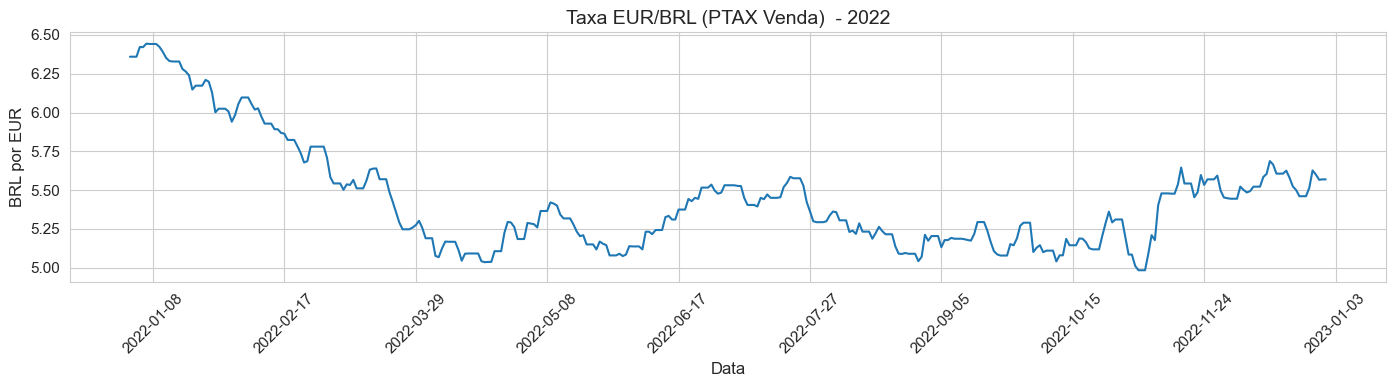

In [13]:
# Para fins de semana e feriados, usamos a taxa do último dia útil (forward fill)

# Criar série de taxas para todos os 365 dias de 2022
todos_os_dias = pd.date_range('2022-01-01', '2022-12-31', freq='D')
df_taxas = pd.Series(taxas_eur_brl).reindex(
    [d.date() for d in todos_os_dias]
).ffill().bfill()

# Mapear taxa para cada registro
df_data['taxa_eur_brl'] = df_data['data'].dt.date.map(df_taxas)

# Calcular valor em BRL:
# - Investimentos: valor_num * taxa (conversão EUR → BRL)
# - Demais métricas: mantém valor_num original (já estão na unidade correta)
df_data['valor_brl'] = np.where(
    df_data['metrica'] == 'investimentos',
    df_data['valor_num'] * df_data['taxa_eur_brl'],
    df_data['valor_num']
)

# Validação
inv = df_data[df_data['metrica'] == 'investimentos']
print(f"Investimento total EUR: {inv['valor_num'].sum():>12,.2f}")
print(f"Investimento total BRL: {inv['valor_brl'].sum():>12,.2f}")
print(f"Taxa média usada:       {inv['taxa_eur_brl'].mean():>12.4f}")
print(f"Registros sem taxa:     {inv['taxa_eur_brl'].isna().sum()}")

# Gráfico: evolução da taxa EUR/BRL em 2022
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_taxas.index, df_taxas.values, color='tab:blue', linewidth=1.5)
ax.set_title('Taxa EUR/BRL (PTAX Venda)  - 2022')
ax.set_xlabel('Data')
ax.set_ylabel('BRL por EUR')
ax.xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Construção da Base Analítica

**O que está sendo feito:**
- Consolidação das colunas necessárias para análises de funil, canal e custo.

**Por que isso importa:**
- Cria uma visão única, reduzindo complexidade e risco de divergência entre etapas.

**Nota metodológica sobre preenchimento de nulos:**
- `NaN` em métricas de volume foi tratado como `0` porque, após o pivot por `data + campanha`, ausência de registro tende a significar ausência de evento no período.
- Essa decisão evita quebra em somas e taxas de funil, mas pode subestimar resultados se houver falha de coleta.
- Nulos de dimensão, como `canal`, não são convertidos em zero e são monitorados por cobertura de mapeamento.

**Observação de governança de naming:**
- No canal `Direto`, há campanhas com nomenclatura heterogênea, incluindo `0`, identificadores técnicos e labels pouco descritivos.
- Isso não invalida o mapeamento de canal, mas reduz rastreabilidade em nível de campanha e pode gerar ambiguidade na leitura executiva.
- Recomendação: padronizar nomenclatura e manter um dicionário de campanhas atualizado.


In [14]:
# Cada linha será uma combinação de data + campanha com todas as métricas como colunas

# 1. Pivotar: uma coluna para cada métrica
df_pivot = df_data.pivot_table(
    index=['data', 'campanha', 'ano_mes', 'mes'],
    columns='metrica',
    values='valor_brl',
    aggfunc='sum'
).reset_index()

df_pivot.columns.name = None

# 2. Renomear colunas para nomes padronizados do funil
renomear_colunas = {
    'clicks': 'cliques',
    'formulario_enviado': 'formularios_enviados',
    'lead': 'leads',
    'agendamento': 'agendamentos',
    'vendas': 'conquistados',
    'investimentos': 'investimento_brl',
}
df_pivot = df_pivot.rename(columns=renomear_colunas)

# 3. Adicionar investimento em EUR (referência)
inv_eur = df_data[df_data['metrica'] == 'investimentos'].pivot_table(
    index=['data', 'campanha'],
    values='valor_num',
    aggfunc='sum'
).rename(columns={'valor_num': 'investimento_eur'}).reset_index()

df_pivot = df_pivot.merge(inv_eur, on=['data', 'campanha'], how='left')

# 4. Merge com campaigns para trazer canal, grupo, tipo_campanha
df_pivot = df_pivot.merge(
    df_campaigns[['campanha', 'tipo_campanha', 'canal', 'grupo']],
    on='campanha',
    how='left'
)

# 5. Preencher NaN de métricas numéricas com 0
metricas_cols = [
    'impressoes', 'cliques', 'sessoes', 'formularios_enviados',
    'leads', 'atribuidos', 'agendamentos', 'conquistados',
    'apps_pagos', 'faturamento', 'investimento_brl', 'investimento_eur'
]
for col in metricas_cols:
    if col in df_pivot.columns:
        df_pivot[col] = df_pivot[col].fillna(0)

# Validação
print(f"Shape: {df_pivot.shape}")
print(f"Colunas: {list(df_pivot.columns)}")
print(f"Cobertura canal: {df_pivot['canal'].notna().mean():.1%}")
print(f"Canais: {sorted(df_pivot['canal'].dropna().unique().tolist())}")
print(f"\nAmostra:")
df_pivot.head(3)

Shape: (73545, 19)
Colunas: ['data', 'campanha', 'ano_mes', 'mes', 'agendamentos', 'apps_pagos', 'atribuidos', 'cliques', 'faturamento', 'formularios_enviados', 'impressoes', 'investimento_brl', 'leads', 'sessoes', 'conquistados', 'investimento_eur', 'tipo_campanha', 'canal', 'grupo']
Cobertura canal: 98.0%
Canais: ['Afiliados', 'CRM', 'Criteo', 'Direto', 'Google Ads', 'Kwai Ads', 'LinkedIn Ads', 'Meta Ads', 'Microsoft Advertising', 'Referral', 'Seedtag', 'Taboola', 'TikTok Ads', 'Weach']

Amostra:


,data,campanha,ano_mes,mes,agendamentos,apps_pagos,atribuidos,cliques,faturamento,formularios_enviados,impressoes,investimento_brl,leads,sessoes,conquistados,investimento_eur,tipo_campanha,canal,grupo
0,2022-01-01,0,2022-01,1,33.0,10.0,40.0,0.0,5500.0,171.0,0.0,0.0,73.0,0.0,33.0,0.0,Direto,Direto,Direto
1,2022-01-01,CRM_pme_Aquisicao_Planejamento_Comercial_Aband...,2022-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,CRM Abandono,CRM,CRM
2,2022-01-01,CRM_pme_Aquisicao_Planejamento_Comercial_Aband...,2022-01,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,CRM Abandono,CRM,CRM


### 6.1 Função auxiliar e definições

**O que está sendo feito:** Definição de funções auxiliares e constantes usadas nas análises subsequentes.

**Por que isso importa:** Centraliza lógica reutilizável (como divisão segura) e garante consistência entre etapas.


In [15]:


# Helpers e definições-base usados nas análises/indicadores das próximas etapas.
# Evita divisões inválidas em métricas derivadas, retornando 0 quando o
# denominador é 0 ou NaN.
def safe_div(num, den):
    """Divisão segura: retorna 0 onde denominador é 0 ou NaN."""
    return np.where((den > 0) & (~np.isnan(den)), num / den, 0)

# Ordem do funil (topo → fundo), conforme definido no case
metricas_funil = [
    'impressoes', 'cliques', 'sessoes', 'formularios_enviados',
    'leads', 'atribuidos', 'agendamentos', 'conquistados', 'apps_pagos'
]

# Labels legíveis para gráficos
labels_funil = [
    'Impressões', 'Cliques', 'Sessões', 'Formulários',
    'Leads', 'Atribuídos', 'Agendamentos', 'Conquistados', 'Apps Pagos'
]

print("Funções auxiliares e definições carregadas.")

Funções auxiliares e definições carregadas.


---
## 7. Análise Exploratória

### 7.1 Performance Geral por Canal

**O que está sendo feito:**
- Comparação de canais por volume de leads, apps pagos e taxas de conversão.
- Identificação de canais com maior escala e canais com maior eficiência relativa.

**Por que isso importa:**
- Direciona priorização de canais que maximizam resultado com verba limitada.
- Separa canais de awareness de canais de fechamento para decisões mais precisas.

**Nota:** a taxa Cliques -> Sessões pode superar 100% porque sessões incluem retornos orgânicos, múltiplas visitas por clique e sessões de canais sem rastreamento de clique.


In [16]:
# Agregação de todas as métricas do funil + investimento por canal e calculamos indicadores de eficiência

canal_agg = df_pivot.groupby('canal').agg(
    impressoes=('impressoes', 'sum'),
    cliques=('cliques', 'sum'),
    sessoes=('sessoes', 'sum'),
    formularios_enviados=('formularios_enviados', 'sum'),
    leads=('leads', 'sum'),
    atribuidos=('atribuidos', 'sum'),
    agendamentos=('agendamentos', 'sum'),
    conquistados=('conquistados', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    faturamento=('faturamento', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
).reset_index()

# Métricas derivadas de eficiência
canal_agg['ctr'] = safe_div(canal_agg['cliques'], canal_agg['impressoes'])
canal_agg['cvr_sessao_lead'] = safe_div(canal_agg['leads'], canal_agg['sessoes'])
canal_agg['cvr_lead_app'] = safe_div(canal_agg['apps_pagos'], canal_agg['leads'])
canal_agg['cpl'] = safe_div(canal_agg['investimento_brl'], canal_agg['leads'])
canal_agg['cpa'] = safe_div(canal_agg['investimento_brl'], canal_agg['apps_pagos'])

canal_agg = canal_agg.sort_values('investimento_brl', ascending=False)

# Exibir colunas mais relevantes
display_cols = ['canal', 'sessoes', 'leads', 'apps_pagos', 'investimento_brl',
                'cvr_sessao_lead', 'cvr_lead_app', 'cpl', 'cpa']
print("Performance por Canal:\n")
print(canal_agg[display_cols].to_string(index=False, float_format='{:,.2f}'.format))

Performance por Canal:

                canal      sessoes      leads  apps_pagos  investimento_brl  cvr_sessao_lead  cvr_lead_app   cpl    cpa
           Google Ads 1,555,306.00  76,516.00   20,090.00        363,376.92             0.05          0.26  4.75  18.09
                Weach   473,269.00   4,389.00    1,037.00        196,483.08             0.01          0.24 44.77 189.47
            Afiliados     5,881.00     433.00      113.00         13,915.52             0.07          0.26 32.14 123.15
Microsoft Advertising   128,341.00   2,410.00      751.00          2,412.10             0.02          0.31  1.00   3.21
             Referral    22,233.00   1,694.00      300.00             43.73             0.08          0.18  0.03   0.15
                  CRM   259,365.00  22,363.00    4,463.00              0.00             0.09          0.20  0.00   0.00
             Kwai Ads    42,992.00       7.00        0.00              0.00             0.00          0.00  0.00   0.00
               D

Visao Geral por Canal - 2022:

                canal   leads  apps_pagos  investimento_brl
               Direto 140,582      39,280                 0
           Google Ads  76,516      20,090           363,377
                  CRM  22,363       4,463                 0
             Meta Ads   7,757       1,547                 0
                Weach   4,389       1,037           196,483
Microsoft Advertising   2,410         751             2,412
             Referral   1,694         300                44
            Afiliados     433         113            13,916
           TikTok Ads      65           3                 0
               Criteo      49          13                 0
         LinkedIn Ads      12           0                 0
             Kwai Ads       7           0                 0
              Taboola       3           0                 0
              Seedtag       1           1                 0



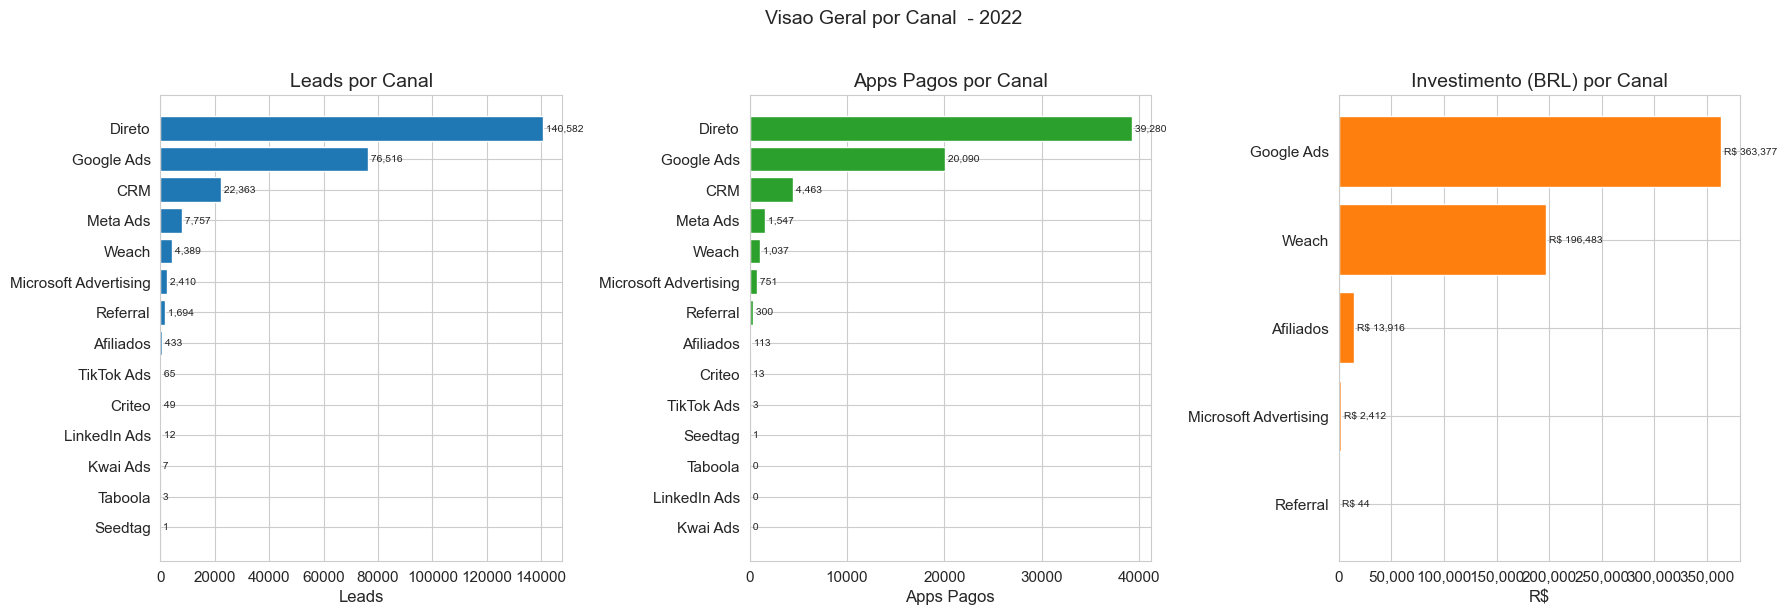

In [17]:
# Tabela numérica: visão geral por canal
tabela_canal = canal_agg[['canal', 'leads', 'apps_pagos', 'investimento_brl']].sort_values('leads', ascending=False)
print("Visao Geral por Canal - 2022:\n")
print(tabela_canal.to_string(index=False, float_format='{:,.0f}'.format))
print()

# Visualização dos 3 indicadores principais para comparação rápida entre canais

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Leads por canal (ordenado por leads decrescente, maior no topo)
canal_por_leads = canal_agg.sort_values("leads", ascending=True)
axes[0].barh(canal_por_leads["canal"], canal_por_leads["leads"], color="tab:blue")
axes[0].set_title("Leads por Canal")
axes[0].set_xlabel("Leads")
for indice, valor in enumerate(canal_por_leads["leads"]):
    axes[0].text(valor, indice, f" {valor:,.0f}", va="center", fontsize=7.5)

# Apps Pagos por canal (ordenado por apps_pagos decrescente, maior no topo)
canal_por_apps = canal_agg.sort_values("apps_pagos", ascending=True)
axes[1].barh(canal_por_apps["canal"], canal_por_apps["apps_pagos"], color="tab:green")
axes[1].set_title("Apps Pagos por Canal")
axes[1].set_xlabel("Apps Pagos")
for indice, valor in enumerate(canal_por_apps["apps_pagos"]):
    axes[1].text(valor, indice, f" {valor:,.0f}", va="center", fontsize=7.5)

# Investimento por canal (apenas canais pagos, ordenado por investimento decrescente)
canal_investimento = canal_agg[canal_agg["investimento_brl"] > 0].sort_values("investimento_brl", ascending=True)
axes[2].barh(canal_investimento["canal"], canal_investimento["investimento_brl"], color="tab:orange")
axes[2].set_title("Investimento (BRL) por Canal")
axes[2].set_xlabel("R$")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for indice, valor in enumerate(canal_investimento["investimento_brl"]):
    axes[2].text(valor, indice, f" R$ {valor:,.0f}", va="center", fontsize=7.5)

plt.suptitle("Visao Geral por Canal  - 2022", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 7.2 Performance por Tipo de Campanha

**O que está sendo feito:**
- Ranking dos 15 tipos de campanha com maior volume de leads para identificar estratégias dominantes.

**Por que isso importa:**
- Permite comparar tipos dentro de um mesmo canal e identificar onde concentrar ou redistribuir verba.

Top 15 Tipos de Campanha por Leads:

                      tipo_campanha      leads  apps_pagos  investimento_brl  cvr_lead_app   cpl
                             Direto 140,582.00   39,280.00              0.00          0.28  0.00
      Google Search Geral Aquisição  31,479.00    8,580.00         21,722.53          0.27  0.69
    Google Search Branded Aquisição  24,268.00    6,685.00              0.00          0.28  0.00
                       CRM Abandono  16,761.00    3,409.00              0.00          0.20  0.00
    Google Search Geral Remarketing   8,887.00    2,255.00            356.96          0.25  0.04
Google Search Non Branded Aquisição   5,267.00    1,328.00              0.00          0.25  0.00
              Google PMax Aquisição   4,845.00      974.00        341,297.43          0.20 70.44
                    Weach Aquisição   4,389.00    1,037.00        196,483.08          0.24 44.77
                      CRM Aquisição   4,311.00      798.00              0.00          0.19

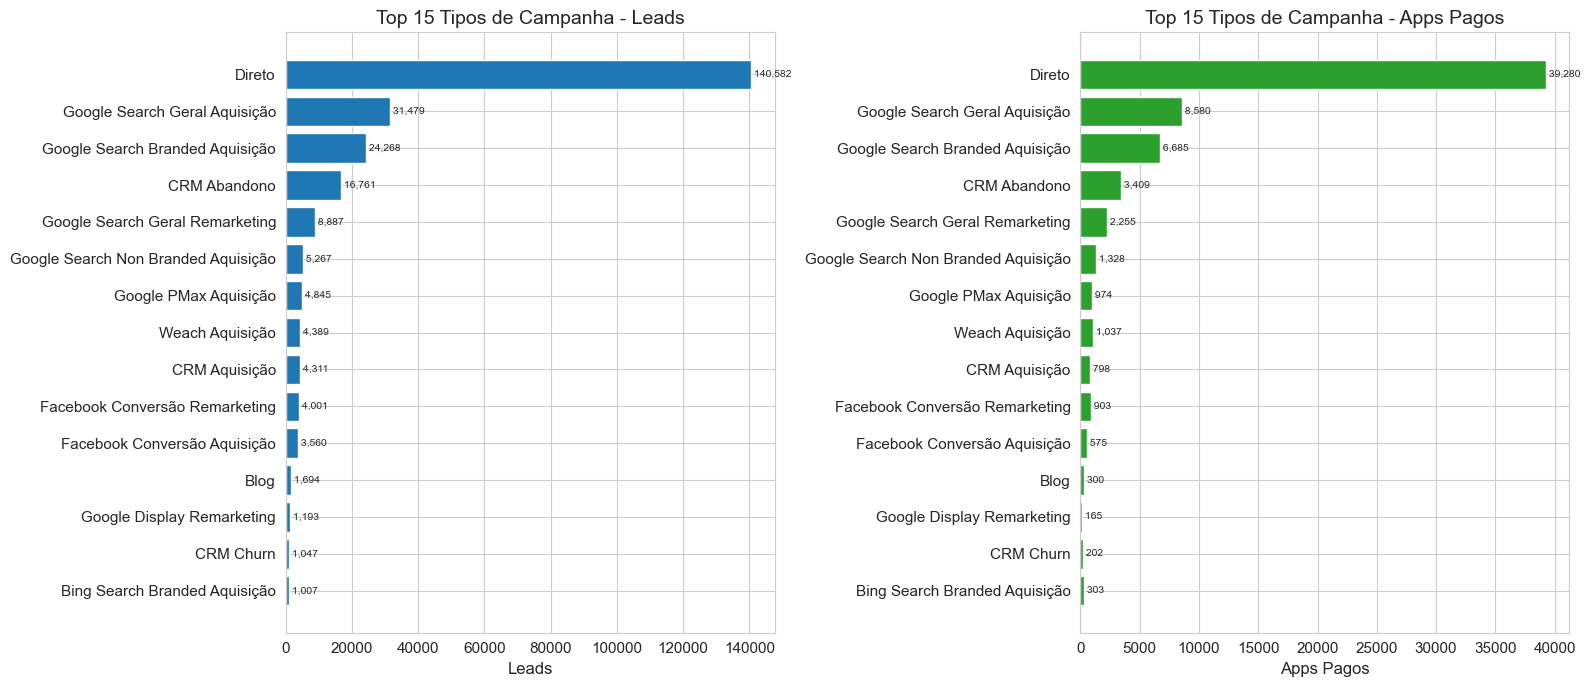

In [18]:
# Top 15 tipos por volume de leads para ajudar a entender quais estratégias geram mais volume

tipo_agregado = df_pivot.groupby('tipo_campanha').agg(
    leads=('leads', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
    sessoes=('sessoes', 'sum'),
).reset_index()

tipo_agregado['cvr_lead_app'] = safe_div(tipo_agregado['apps_pagos'], tipo_agregado['leads'])
tipo_agregado['cpl'] = safe_div(tipo_agregado['investimento_brl'], tipo_agregado['leads'])

top_tipos = tipo_agregado.nlargest(15, 'leads').sort_values('leads', ascending=True)

# Tabela numérica
tabela_top15 = top_tipos.sort_values('leads', ascending=False)[
    ['tipo_campanha', 'leads', 'apps_pagos', 'investimento_brl', 'cvr_lead_app', 'cpl']
]
print("Top 15 Tipos de Campanha por Leads:\n")
print(tabela_top15.to_string(index=False, float_format='{:,.2f}'.format))
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_tipos['tipo_campanha'], top_tipos['leads'], color='tab:blue')
axes[0].set_title('Top 15 Tipos de Campanha - Leads')
axes[0].set_xlabel('Leads')
for indice, valor in enumerate(top_tipos['leads']):
    axes[0].text(valor, indice, f' {valor:,.0f}', va='center', fontsize=7.5)

axes[1].barh(top_tipos['tipo_campanha'], top_tipos['apps_pagos'], color='tab:green')
axes[1].set_title('Top 15 Tipos de Campanha - Apps Pagos')
axes[1].set_xlabel('Apps Pagos')
for indice, valor in enumerate(top_tipos['apps_pagos']):
    axes[1].text(valor, indice, f' {valor:,.0f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

### 7.3 Performance por Grupo (Pago, CRM, Direto, Referral)

**O que está sendo feito:**
- Agregação de métricas por grupo macro (Pago, CRM, Direto, Referral) para visão consolidada.

**Por que isso importa:**
- Revela a contribuição relativa de cada grupo e justifica onde priorizar esforço e investimento.

In [19]:
# Visão macro: quanto cada grupo contribui para o resultado total

grupo_agg = df_pivot.groupby('grupo').agg(
    sessoes=('sessoes', 'sum'),
    leads=('leads', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    faturamento=('faturamento', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
).reset_index()

grupo_agg['cvr_sessao_lead'] = safe_div(grupo_agg['leads'], grupo_agg['sessoes'])
grupo_agg['cvr_lead_app'] = safe_div(grupo_agg['apps_pagos'], grupo_agg['leads'])
grupo_agg['cpl'] = safe_div(grupo_agg['investimento_brl'], grupo_agg['leads'])
grupo_agg['cpa'] = safe_div(grupo_agg['investimento_brl'], grupo_agg['apps_pagos'])
grupo_agg['share_leads'] = grupo_agg['leads'] / grupo_agg['leads'].sum()
grupo_agg['share_apps'] = grupo_agg['apps_pagos'] / grupo_agg['apps_pagos'].sum()

print("Performance por Grupo:\n")
print(grupo_agg.to_string(index=False, float_format='{:,.2f}'.format))

Performance por Grupo:

   grupo      sessoes      leads  apps_pagos   faturamento  investimento_brl  cvr_sessao_lead  cvr_lead_app  cpl   cpa  share_leads  share_apps
     CRM   259,365.00  22,363.00    4,463.00  2,183,500.00              0.00             0.09          0.20 0.00  0.00         0.09        0.07
  Direto    36,625.00 140,582.00   39,280.00 19,119,500.00              0.00             3.84          0.28 0.00  0.00         0.55        0.58
    Pago 2,817,894.00  91,642.00   23,555.00 11,518,000.00        576,187.62             0.03          0.26 6.29 24.46         0.36        0.35
Referral    22,233.00   1,694.00      300.00    146,500.00             43.73             0.08          0.18 0.03  0.15         0.01        0.00


---
## 8. Análise do Funil por Canal

Funil: Impressões -> Cliques -> Sessões -> Formulários -> Leads -> Atribuídos -> Agendamentos -> Conquistados -> Apps Pagos

**O que está sendo feito:**
- Medição de volume absoluto e taxa de passagem entre etapas consecutivas do funil por canal.
- Construção de duas visões normalizadas complementares para comparação justa de formato.
- Visão 1: canais pagos com base em Impressões = 100 (funil completo).
- Visão 2: todos os canais com base em Leads = 100 (foco em meio/fundo).
- Exposição transparente dos canais pagos excluídos da Visão 1 quando `impressões = 0`.

**Por que isso importa:**
- Evita comparar canais com bases de topo incompatíveis em um único gráfico.
- Separa a leitura de eficiência de aquisição paga (topo completo) da eficiência comercial (meio/fundo).
- Regra de interpretação: comparar formato relativo das curvas, sem inferir causalidade.


In [20]:
# Objetivo: Consolidar o funil por canal em volume absoluto para leitura de escala por etapa.
# Leitura prática: Mostra quais canais concentram maior volume bruto ao longo do funil.

# Funil por canal - volume absoluto
# Nota: impressões e cliques existem apenas para canais pagos com mídia display/search

funil_canal = df_pivot.groupby('canal')[metricas_funil].sum()
funil_canal = funil_canal.sort_values('leads', ascending=False)

print("Volume absoluto do funil por canal:\n")
print(funil_canal.to_string(float_format='{:,.0f}'.format))


Volume absoluto do funil por canal:

                       impressoes  cliques   sessoes  formularios_enviados   leads  atribuidos  agendamentos  conquistados  apps_pagos
canal                                                                                                                                 
Direto                          0        0    36,625               299,512 140,582      89,593        72,595        68,617      39,280
Google Ads             38,054,974  303,741 1,555,306               278,484  76,516      48,857        37,327        35,298      20,090
CRM                             0        0   259,365                62,083  22,363      13,918         9,696         9,005       4,463
Meta Ads                        0        0   505,877                38,186   7,757       4,641         3,195         2,976       1,547
Weach                           0        0   473,269                14,212   4,389       2,775         2,134         1,992       1,037
Microsoft Advertis

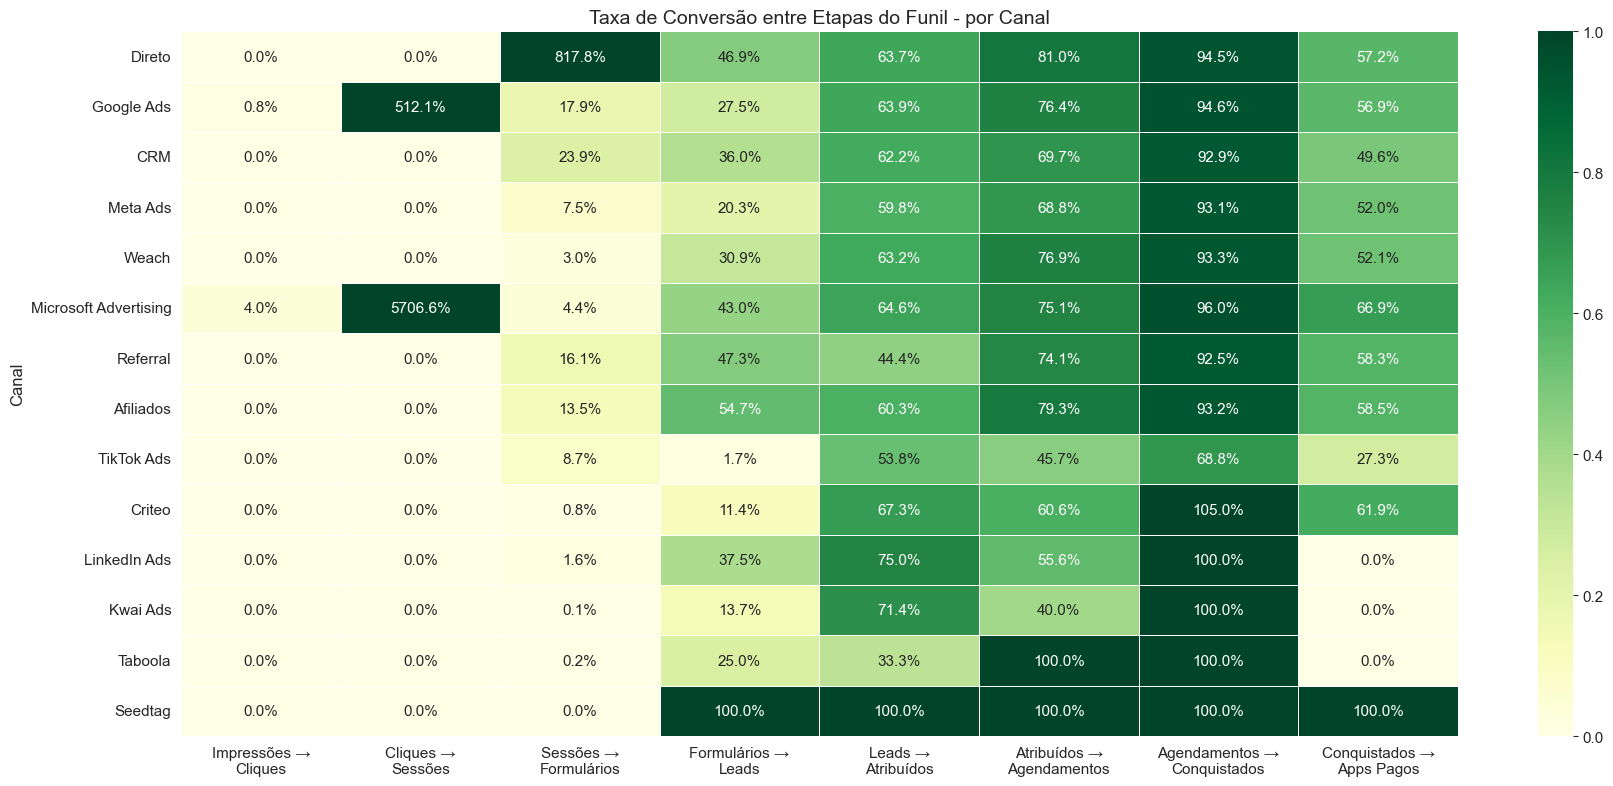

In [21]:
# Objetivo: Calcular a taxa de passagem entre etapas consecutivas do funil por canal.
# Leitura prática: Evidencia eficiência relativa entre etapas, independentemente do volume total.

# Heatmap de conversão entre etapas consecutivas do funil
# Cada célula mostra a taxa de passagem de uma etapa para a próxima, por canal

taxas_funil = pd.DataFrame(index=funil_canal.index)
for i in range(len(metricas_funil) - 1):
    col_de = metricas_funil[i]
    col_para = metricas_funil[i + 1]
    label = f'{labels_funil[i]} →\n{labels_funil[i+1]}'
    taxas_funil[label] = safe_div(
        funil_canal[col_para].values, funil_canal[col_de].values
    )

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    taxas_funil, annot=True, fmt='.1%', cmap='YlGn',
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title('Taxa de Conversão entre Etapas do Funil - por Canal')
ax.set_ylabel('Canal')
plt.tight_layout()
plt.show()


Visão 1 - Canais pagos (base em Impressões = 100)
Canais incluídos: 2
Canais pagos excluídos (impressões = 0): Afiliados, Criteo, Kwai Ads, LinkedIn Ads, Meta Ads, Seedtag, Taboola, TikTok Ads, Weach

Funil normalizado (Impressões = 100):

                       impressoes  cliques  sessoes  formularios_enviados  leads  atribuidos  agendamentos  conquistados  apps_pagos
canal                                                                                                                               
Google Ads                  100.0     0.80     4.09                  0.73   0.20        0.13          0.10          0.09        0.05
Microsoft Advertising       100.0     3.98   227.04                  9.92   4.26        2.75          2.07          1.98        1.33



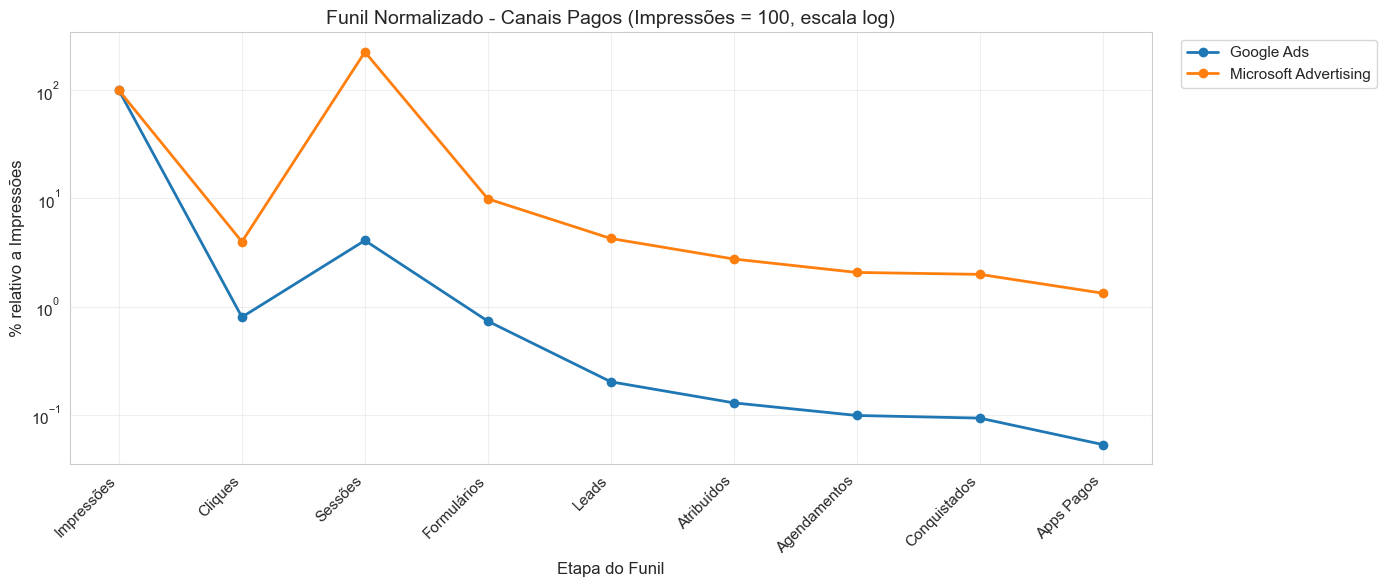

In [40]:
# Objetivo: Construir a Visão 1 do funil normalizado para canais pagos com base em impressões iguais a 100.
# Leitura prática: Permite comparar eficiência de progressão do funil completo entre canais pagos.

# Funil normalizado
# Visão 1: canais pagos com base em Impressões = 100 (funil completo)
# Visão 2: todos os canais com base em Leads = 100 (meio/fundo)

# Preparação da base para segmentar canais pagos e todos os canais.
canal_grupo = (
    df_pivot[['canal', 'grupo']]
    .dropna(subset=['canal'])
    .drop_duplicates(subset=['canal'])
    .set_index('canal')['grupo']
)

funil_norm = funil_canal.copy()
funil_norm['grupo'] = funil_norm.index.map(canal_grupo)


# Visão 1: seleciona canais pagos com impressões válidas para comparação justa.
paid_all = funil_norm[funil_norm['grupo'] == 'Pago'].copy()
paid_valid = paid_all[paid_all['impressoes'] > 0].copy().sort_values('leads', ascending=False)
paid_excluidos = sorted(paid_all[paid_all['impressoes'] <= 0].index.tolist())

print('Visão 1 - Canais pagos (base em Impressões = 100)')
print(f'Canais incluídos: {len(paid_valid)}')
if paid_excluidos:
    print('Canais pagos excluídos (impressões = 0): ' + ', '.join(paid_excluidos))
else:
    print('Canais pagos excluídos (impressões = 0): nenhum')

# Tabela numérica do funil normalizado
# Tabela de apoio da Visão 1: normalização por impressões iguais a 100.
if not paid_valid.empty:
    funil_normalizado = paid_valid[metricas_funil].copy()
    for canal_nome in funil_normalizado.index:
        base_impressoes = funil_normalizado.loc[canal_nome, 'impressoes']
        if base_impressoes > 0:
            funil_normalizado.loc[canal_nome] = (funil_normalizado.loc[canal_nome] / base_impressoes) * 100
    print("\nFunil normalizado (Impressões = 100):\n")
    print(funil_normalizado.round(2).to_string())
    print()

# Gráfico da Visão 1: leitura do funil completo em escala logarítmica.
if paid_valid.empty:
    print('Sem canais pagos com impressões > 0 para plotar.')
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    for canal, row in paid_valid.iterrows():
        valores = row[metricas_funil].values.astype(float)
        valores_norm = (valores / row['impressoes']) * 100
        ax.plot(labels_funil, valores_norm, marker='o', linewidth=2, label=canal)

    ax.set_yscale('log')
    ax.set_title('Funil Normalizado - Canais Pagos (Impressões = 100, escala log)')
    ax.set_ylabel('% relativo a Impressões')
    ax.set_xlabel('Etapa do Funil')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



Visão 2 - Todos os canais (base em Leads = 100, meio/fundo)
Canais incluídos: 14
Canais em destaque (top 8 por leads): 8
Canais na cauda de baixo volume: 6


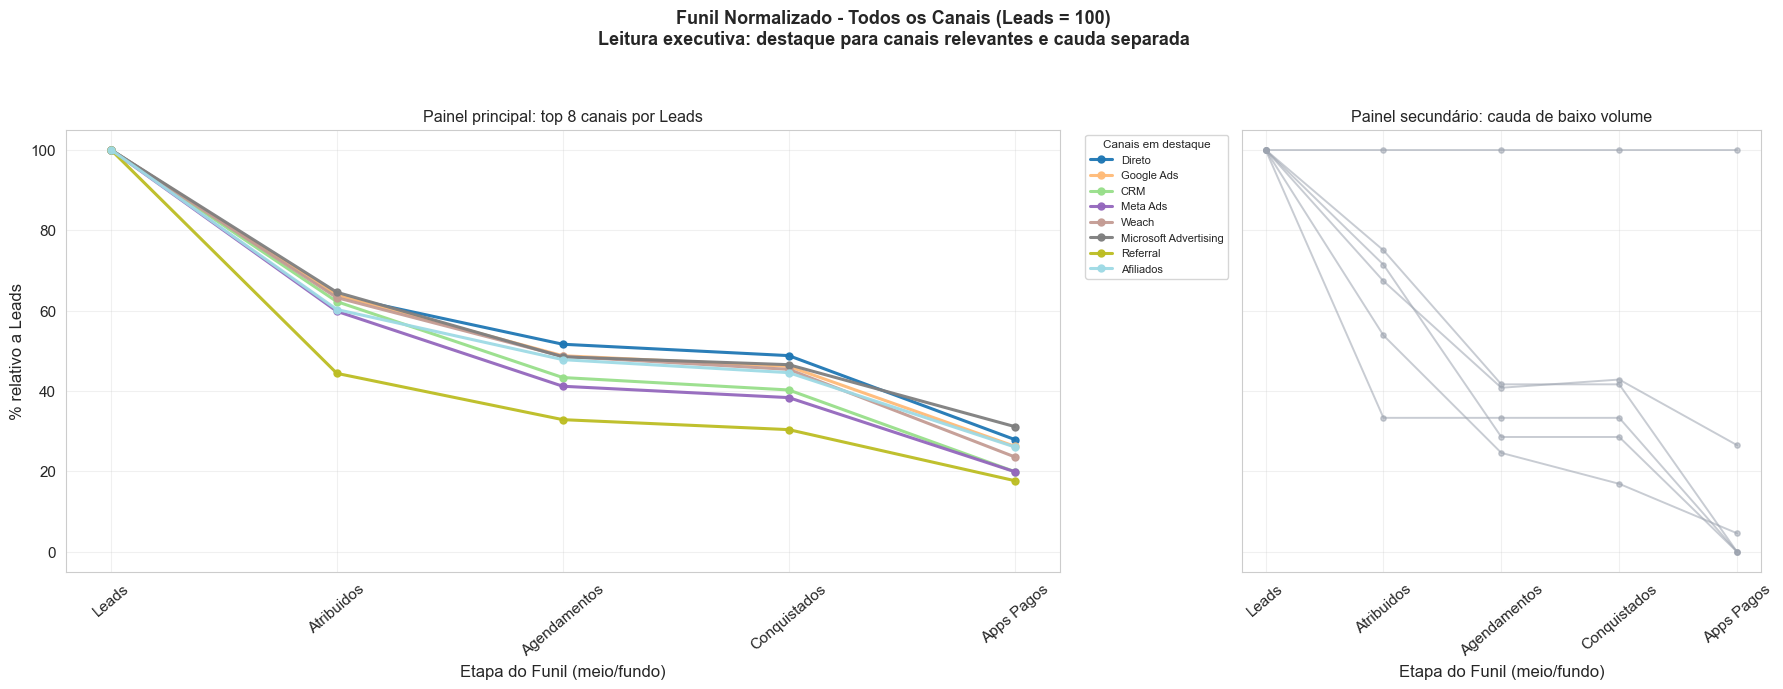


Evidência de leitura (Direto x Seedtag):
         Leads (N)  Atribuidos (%)  Agendamentos (%)  Conquistados (%)  Apps Pagos (%)
Direto      140582            63.7              51.6              48.8            27.9
Seedtag          1           100.0             100.0             100.0           100.0
Direto não é linha reta: cai de 100% em Leads para 27.9% em Apps Pagos.
Seedtag fica em 100% por base unitária: N=1 lead.


In [39]:
# Objetivo: Construir a Visão 2 do funil normalizado para todos os canais com base em leads iguais a 100.
# Leitura prática: Separa canais de maior volume da cauda para leitura executiva sem ambiguidade visual.

stages_meio_fundo = ['leads', 'atribuidos', 'agendamentos', 'conquistados', 'apps_pagos']
labels_meio_fundo = ['Leads', 'Atribuidos', 'Agendamentos', 'Conquistados', 'Apps Pagos']

# Visão 2: normaliza todos os canais com base em leads iguais a 100.
todos_valid = funil_norm[funil_norm['leads'] > 0].copy().sort_values('leads', ascending=False)
top_n = 8

print('')
print('Visão 2 - Todos os canais (base em Leads = 100, meio/fundo)')
print(f'Canais incluídos: {len(todos_valid)}')

if todos_valid.empty:
    print('Sem canais com leads > 0 para plotar.')
else:
    top_canais = todos_valid.head(top_n).copy()
    cauda_canais = todos_valid.iloc[top_n:].copy()

    print(f'Canais em destaque (top {top_n} por leads): {len(top_canais)}')
    print(f'Canais na cauda de baixo volume: {len(cauda_canais)}')

# Visual em dois painéis: destaque dos canais principais e cauda de baixo volume.
    fig, (ax_main, ax_tail) = plt.subplots(
        1, 2,
        figsize=(18, 7),
        sharey=True,
        gridspec_kw={'width_ratios': [2.3, 1.2]}
    )

    # Painel principal com cores únicas
    palette = plt.cm.tab20(np.linspace(0.02, 0.98, max(len(top_canais), 1)))

    for i, (canal, row) in enumerate(top_canais.iterrows()):
        valores = row[stages_meio_fundo].values.astype(float)
        valores_norm = (valores / row['leads']) * 100
        ax_main.plot(
            labels_meio_fundo,
            valores_norm,
            marker='o',
            linewidth=2.2,
            markersize=5,
            alpha=0.95,
            color=palette[i],
            label=canal,
        )

    # Painel secundário para cauda (cinza, sem destaque)
    for _, row in cauda_canais.iterrows():
        valores = row[stages_meio_fundo].values.astype(float)
        valores_norm = (valores / row['leads']) * 100
        ax_tail.plot(
            labels_meio_fundo,
            valores_norm,
            marker='o',
            linewidth=1.4,
            markersize=3.8,
            alpha=0.55,
            color='#9CA3AF',
        )

    for ax in (ax_main, ax_tail):
        ax.grid(True, alpha=0.28)
        ax.set_xlabel('Etapa do Funil (meio/fundo)')
        ax.tick_params(axis='x', rotation=40)

    ax_main.set_title(f'Painel principal: top {top_n} canais por Leads', fontsize=11.5)
    ax_tail.set_title('Painel secundário: cauda de baixo volume', fontsize=11.5)
    ax_main.set_ylabel('% relativo a Leads')

    ax_main.legend(
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        frameon=True,
        title='Canais em destaque',
        fontsize=8,
        title_fontsize=8.5,
    )

    fig.suptitle(
        'Funil Normalizado - Todos os Canais (Leads = 100)\n'
        'Leitura executiva: destaque para canais relevantes e cauda separada',
        fontsize=13,
        fontweight='bold',
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    # Evidência curta para desfazer ambiguidade Direto x Seedtag
# Evidência objetiva para leitura de Direto e Seedtag sem ambiguidade.
    norm_pct = todos_valid[stages_meio_fundo].div(todos_valid['leads'], axis=0) * 100
    canais_ref = [c for c in ['Direto', 'Seedtag'] if c in norm_pct.index]

    if canais_ref:
        evidencia = pd.DataFrame(index=canais_ref)
        evidencia['Leads (N)'] = todos_valid.loc[canais_ref, 'leads'].astype(int)
        evidencia['Atribuidos (%)'] = norm_pct.loc[canais_ref, 'atribuidos']
        evidencia['Agendamentos (%)'] = norm_pct.loc[canais_ref, 'agendamentos']
        evidencia['Conquistados (%)'] = norm_pct.loc[canais_ref, 'conquistados']
        evidencia['Apps Pagos (%)'] = norm_pct.loc[canais_ref, 'apps_pagos']

        print('')
        print('Evidência de leitura (Direto x Seedtag):')
        print(evidencia.to_string(float_format='{:,.1f}'.format))

    if 'Direto' in norm_pct.index:
        print(
            f"Direto não é linha reta: cai de 100% em Leads para {norm_pct.at['Direto', 'apps_pagos']:.1f}% em Apps Pagos."
        )

    if 'Seedtag' in norm_pct.index:
        print(
            f"Seedtag fica em 100% por base unitária: N={int(todos_valid.at['Seedtag', 'leads'])} lead."
        )


---
## 9. Leads por Mês e Sazonalidade

**O que está sendo feito:**
- Leitura da evolução mensal de leads totais e por canal para detectar padrão sazonal.

**Por que isso importa:**
- Apoia planejamento de verba e metas por período, evitando comparações injustas entre meses.


Tabela mensal de leads:
 mes  nome_mes  leads
   1   Janeiro 22,801
   2 Fevereiro 22,447
   3     Março 28,122
   4     Abril 23,018
   5      Maio 23,957
   6     Junho 20,220
   7     Julho 19,433
   8    Agosto 21,717
   9  Setembro 20,941
  10   Outubro 20,509
  11  Novembro 20,365
  12  Dezembro 14,686

Resumo curto de sazonalidade:
Pico anual: Março com 28,122 leads
Faixa intermediária: Maio (23,957), Abril (23,018), Janeiro (22,801), Fevereiro (22,447)
Vale anual: Dezembro (14,686), Julho (19,433), Junho (20,220)
Nota: Janeiro sem variação MoM (primeiro mês da série)


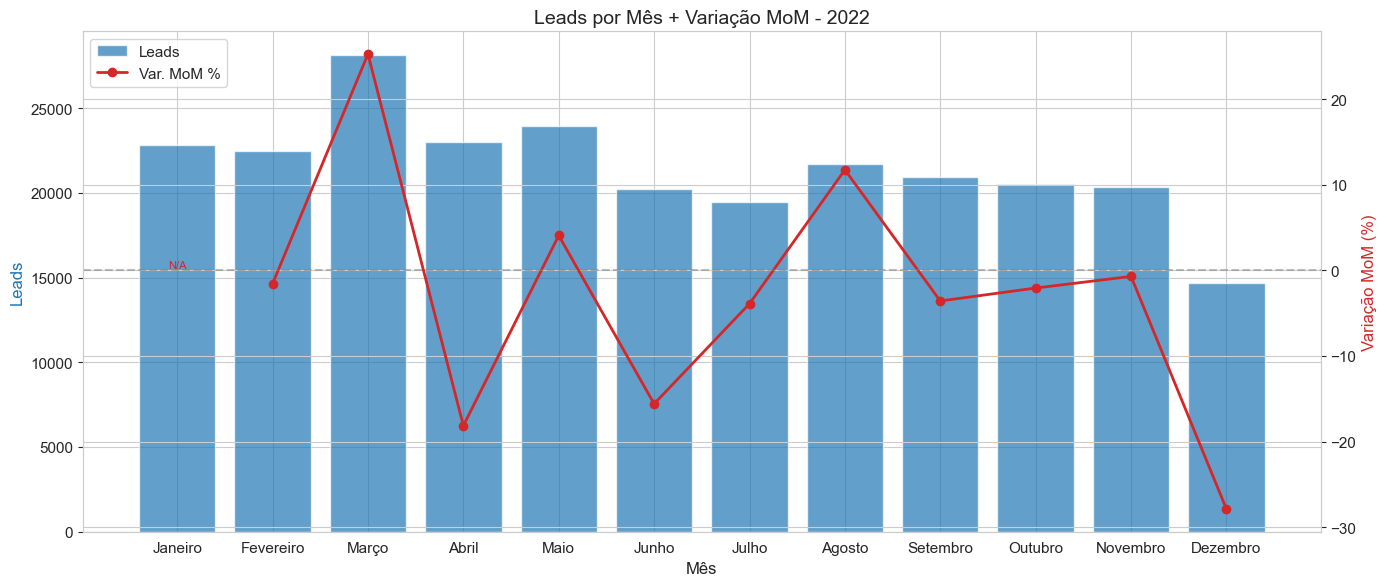

In [24]:
# Leads por mês + variação mês a mês (MoM)
# identificar padrões de sazonalidade na geração de leads

leads_mes = df_pivot.groupby('mes')['leads'].sum().reset_index()
mapa_meses = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
    7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}
leads_mes['nome_mes'] = leads_mes['mes'].map(mapa_meses)
leads_mes['variacao_mom'] = leads_mes['leads'].pct_change()

# Evidência textual para rastreabilidade direta dos números usados nas conclusões executivas
print('Tabela mensal de leads:')
print(leads_mes[['mes', 'nome_mes', 'leads']].to_string(index=False, float_format='{:,.0f}'.format))

pico = leads_mes.loc[leads_mes['leads'].idxmax(), ['nome_mes', 'leads']]
vales = leads_mes.nsmallest(3, 'leads')[['nome_mes', 'leads']]
intermediarios = leads_mes.sort_values('leads', ascending=False).iloc[1:5][['nome_mes', 'leads']]

intermediarios_texto = ', '.join([f"{r['nome_mes']} ({r['leads']:,.0f})" for _, r in intermediarios.iterrows()])
vales_texto = ', '.join([f"{r['nome_mes']} ({r['leads']:,.0f})" for _, r in vales.iterrows()])

print('\nResumo curto de sazonalidade:')
print(f"Pico anual: {pico['nome_mes']} com {pico['leads']:,.0f} leads")
print(f"Faixa intermediária: {intermediarios_texto}")
print(f"Vale anual: {vales_texto}")
print("Nota: Janeiro sem variação MoM (primeiro mês da série)")

fig, eixo_principal = plt.subplots(figsize=(14, 6))

# Barras: volume mensal de leads
eixo_principal.bar(leads_mes['nome_mes'], leads_mes['leads'], color='tab:blue', alpha=0.7, label='Leads')
eixo_principal.set_ylabel('Leads', color='tab:blue')
eixo_principal.set_xlabel('Mês')
eixo_principal.set_title('Leads por Mês + Variação MoM - 2022')

# Linha: variação percentual MoM (eixo secundário)
eixo_secundario = eixo_principal.twinx()
eixo_secundario.plot(leads_mes['nome_mes'], leads_mes['variacao_mom'] * 100,
         color='tab:red', marker='o', linewidth=2, label='Var. MoM %')
eixo_secundario.set_ylabel('Variação MoM (%)', color='tab:red')
eixo_secundario.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Anotação N/A em Janeiro (sem mês anterior para calcular MoM)
eixo_secundario.annotate('N/A', (leads_mes['nome_mes'].iloc[0], 0),
             fontsize=8, color='tab:red', ha='center', va='bottom')

# Legenda combinada
linhas1, rotulos1 = eixo_principal.get_legend_handles_labels()
linhas2, rotulos2 = eixo_secundario.get_legend_handles_labels()
eixo_principal.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc='upper left')

plt.tight_layout()
plt.show()

Leads por Mes - Top 5 Canais:

              Jan    Feb    Mar    Apr    May    Jun    Jul   Aug   Sep    Oct    Nov   Dec   Total
canal                                                                                              
Direto     12,864 15,325 15,953 12,926 12,784 10,597 10,653 9,582 9,650 10,143 12,864 7,241 140,582
Google Ads  7,354  4,913  8,851  7,365  8,573  6,632  5,478 6,748 6,201  5,722  4,121 4,558  76,516
CRM         1,995  1,565  2,116  1,633  1,298  1,300  1,105 2,578 2,427  2,640  2,052 1,654  22,363
Meta Ads      218    244    367     91    171    464  1,109 1,544 1,304  1,001    729   515   7,757
Weach          89    269    539    504    590    666    537   285   391    276     94   149   4,389



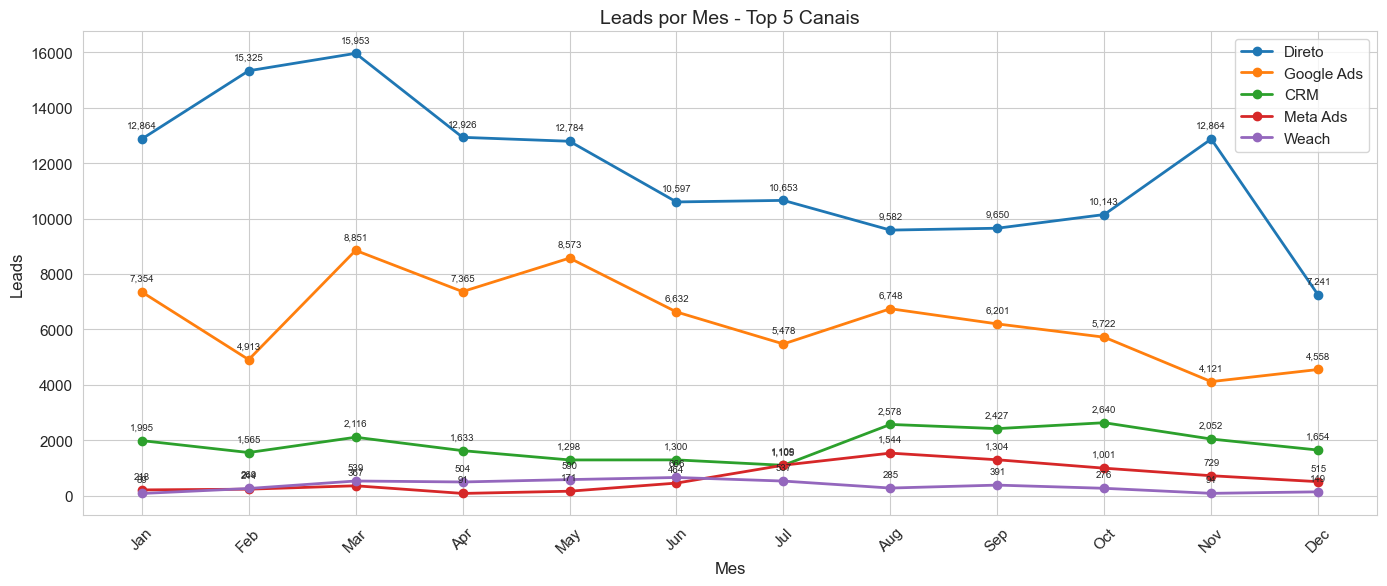

In [25]:
# Leads por mês - top 5 canais
# Desdobra a sazonalidade por canal para entender o que impulsiona os picos e vales

top5 = df_pivot.groupby('canal')['leads'].sum().nlargest(5).index.tolist()

leads_canal_mes = df_pivot[df_pivot['canal'].isin(top5)].groupby(
    ['mes', 'canal']
)['leads'].sum().reset_index()

# Meses fixos 1-12 para manter eixo X alinhado entre canais
meses_fixos = list(range(1, 13))
meses_labels = pd.to_datetime(meses_fixos, format='%m').strftime('%b')

# Tabela numérica: leads por mês para os top 5 canais
tabela_leads_canal = leads_canal_mes.pivot(index='canal', columns='mes', values='leads').reindex(columns=meses_fixos, fill_value=0)
tabela_leads_canal.columns = meses_labels
tabela_leads_canal['Total'] = tabela_leads_canal.sum(axis=1)
tabela_leads_canal = tabela_leads_canal.sort_values('Total', ascending=False)
print("Leads por Mes - Top 5 Canais:\n")
print(tabela_leads_canal.to_string(float_format='{:,.0f}'.format))
print()

fig, eixo = plt.subplots(figsize=(14, 6))
for canal in top5:
    dados = leads_canal_mes[leads_canal_mes['canal'] == canal]
    # Reindexar para garantir todos os 12 meses (preenche com 0 se ausente)
    dados_completo = dados.set_index('mes').reindex(meses_fixos, fill_value=0)
    valores = dados_completo['leads'].values
    eixo.plot(meses_labels, valores, marker='o', linewidth=2, label=canal)
    # Anotações de valor em cada ponto
    for indice_mes, valor_leads in enumerate(valores):
        if valor_leads > 0:
            eixo.annotate(f'{valor_leads:,.0f}', (meses_labels[indice_mes], valor_leads),
                         textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)

eixo.set_title('Leads por Mes - Top 5 Canais')
eixo.set_xlabel('Mes')
eixo.set_ylabel('Leads')
eixo.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## 10. Performance por Tipo de Campanha (Canais Pagos)

Dentro de canais pagos, qual tipo de campanha tem melhor desempenho em cada etapa do funil?

**O que está sendo feito:**
- Comparação entre tipos pagos considerando volume, conversão e equilíbrio escala-eficiência.

**Por que isso importa:**
- Orienta realocação de verba para tipos com melhor retorno esperado.


In [26]:
# Objetivo: Consolidar desempenho por tipo de campanha paga e derivar métricas de eficiência e custo.
# Leitura prática: Gera a base comparável para priorizar tipos pagos com melhor retorno operacional.

# Entender quais estratégias de mídia paga convertem melhor em cada etapa

# Recorte inicial: mantém somente campanhas do grupo pago.
df_pago = df_pivot[df_pivot['grupo'] == 'Pago'].copy()

# Agregação por tipo de campanha para comparar resultados na mesma base.
pago_tipo = df_pago.groupby('tipo_campanha').agg(
    impressoes=('impressoes', 'sum'),
    cliques=('cliques', 'sum'),
    sessoes=('sessoes', 'sum'),
    leads=('leads', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    investimento_brl=('investimento_brl', 'sum'),
).reset_index()

# Métricas derivadas
pago_tipo['ctr'] = safe_div(pago_tipo['cliques'], pago_tipo['impressoes'])
pago_tipo['cvr_sessao_lead'] = safe_div(pago_tipo['leads'], pago_tipo['sessoes'])
pago_tipo['cvr_lead_app'] = safe_div(pago_tipo['apps_pagos'], pago_tipo['leads'])
pago_tipo['cpl'] = safe_div(pago_tipo['investimento_brl'], pago_tipo['leads'])
pago_tipo['cpa'] = safe_div(pago_tipo['investimento_brl'], pago_tipo['apps_pagos'])

# Filtrar tipos com volume mínimo relevante (>= 10 leads)
pago_tipo_relevante = pago_tipo[pago_tipo['leads'] >= 10].sort_values('leads', ascending=False)

print(f"Tipos pagos com >= 10 leads: {len(pago_tipo_relevante)}\n")
print(pago_tipo_relevante[
    ['tipo_campanha', 'leads', 'apps_pagos', 'investimento_brl', 'cvr_lead_app', 'cpl', 'cpa']
].to_string(index=False, float_format='{:,.2f}'.format))


Tipos pagos com >= 10 leads: 25

                      tipo_campanha     leads  apps_pagos  investimento_brl  cvr_lead_app   cpl    cpa
      Google Search Geral Aquisição 31,479.00    8,580.00         21,722.53          0.27  0.69   2.53
    Google Search Branded Aquisição 24,268.00    6,685.00              0.00          0.28  0.00   0.00
    Google Search Geral Remarketing  8,887.00    2,255.00            356.96          0.25  0.04   0.16
Google Search Non Branded Aquisição  5,267.00    1,328.00              0.00          0.25  0.00   0.00
              Google PMax Aquisição  4,845.00      974.00        341,297.43          0.20 70.44 350.41
                    Weach Aquisição  4,389.00    1,037.00        196,483.08          0.24 44.77 189.47
     Facebook Conversão Remarketing  4,001.00      903.00              0.00          0.23  0.00   0.00
       Facebook Conversão Aquisição  3,560.00      575.00              0.00          0.16  0.00   0.00
         Google Display Remarketing  1,1

In [27]:
# Objetivo: Preparar os recortes com e sem investimento para o scatter executivo da etapa 10.
# Leitura prática: Organiza os dados que suportam a leitura conjunta de volume, eficiência e custo.

# Scatter executivo: Volume (leads) x eficiência (CVR lead->app) x custo (CPA)
# X = leads (log), Y = CVR, tamanho = investimento, cor = CPA.
# Leitura enxuta: somente campanhas-chave rotuladas; em area densa, rótulos secundários sao ocultados.

# Separar tipos com e sem investimento rastreado
# Segmentação para separar campanhas com e sem investimento rastreado.
com_inv = pago_tipo_relevante[pago_tipo_relevante['investimento_brl'] > 0].copy()
sem_inv = pago_tipo_relevante[pago_tipo_relevante['investimento_brl'] == 0].copy()


Canais pagos - volume x eficiencia x custo (tipos com >=10 leads):

                      tipo_campanha     leads  apps_pagos  investimento_brl  cvr_lead_app_%    cpa   cpl
      Google Search Geral Aquisição 31,479.00    8,580.00         21,722.53           27.26   2.53  0.69
    Google Search Branded Aquisição 24,268.00    6,685.00              0.00           27.55   0.00  0.00
    Google Search Geral Remarketing  8,887.00    2,255.00            356.96           25.37   0.16  0.04
Google Search Non Branded Aquisição  5,267.00    1,328.00              0.00           25.21   0.00  0.00
              Google PMax Aquisição  4,845.00      974.00        341,297.43           20.10 350.41 70.44
                    Weach Aquisição  4,389.00    1,037.00        196,483.08           23.63 189.47 44.77
     Facebook Conversão Remarketing  4,001.00      903.00              0.00           22.57   0.00  0.00
       Facebook Conversão Aquisição  3,560.00      575.00              0.00           16.15 

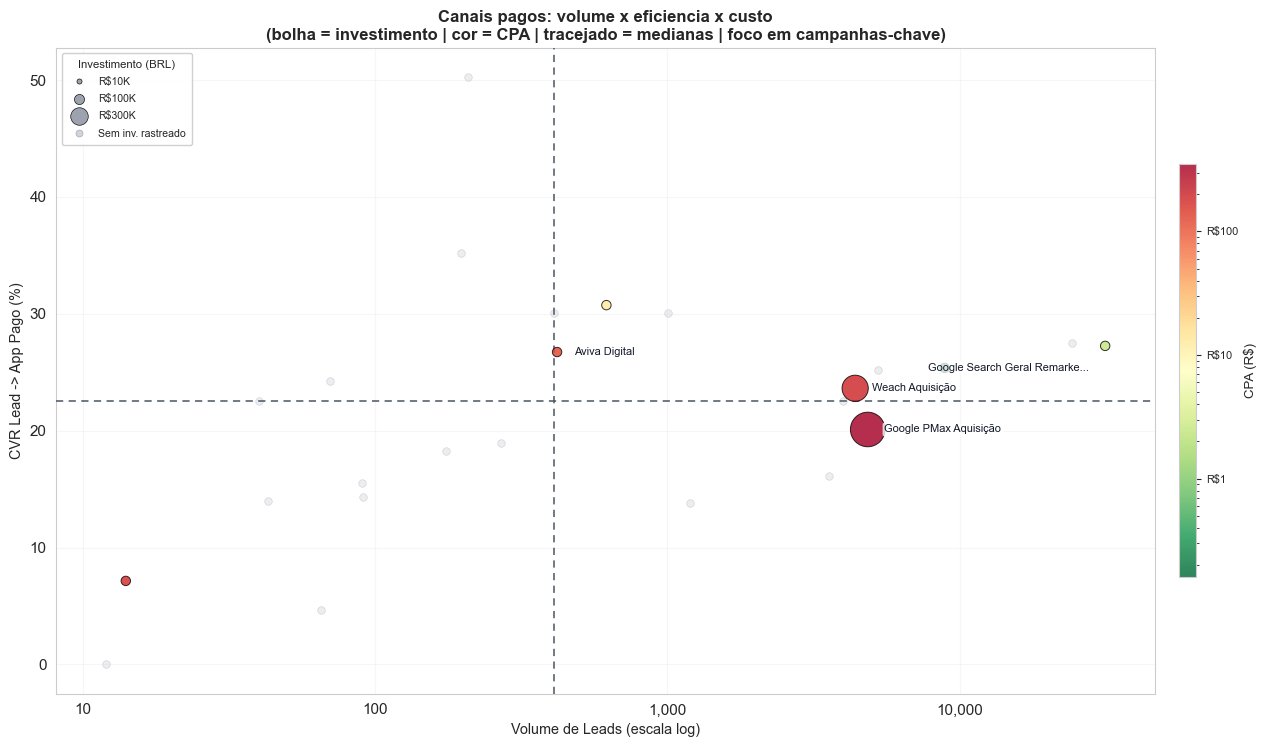

In [28]:
# Objetivo: Exibir a tabela numérica e o scatter executivo com foco em campanhas chave.
# Leitura prática: Facilita decisão de alocação ao combinar leads, CVR, CPA e investimento no mesmo plano.

# Tabela numérica: métricas dos tipos de campanha paga (>=10 leads)
# Tabela numérica de apoio para validar os pontos exibidos no gráfico.
colunas_scatter = ['tipo_campanha', 'leads', 'apps_pagos', 'investimento_brl', 'cvr_lead_app', 'cpa', 'cpl']
tabela_scatter = pago_tipo_relevante[colunas_scatter].sort_values('leads', ascending=False).copy()
tabela_scatter['cvr_lead_app'] = tabela_scatter['cvr_lead_app'] * 100
tabela_scatter = tabela_scatter.rename(columns={'cvr_lead_app': 'cvr_lead_app_%'})
print("Canais pagos - volume x eficiencia x custo (tipos com >=10 leads):\n")
print(tabela_scatter.to_string(index=False, float_format='{:,.2f}'.format))
print()

# Construção do scatter executivo com foco em legibilidade e priorização.
fig, ax = plt.subplots(figsize=(14, 7.6))

# --- Pontos sem investimento (cinza claro, sem rótulo) ---
ax.scatter(
    sem_inv['leads'],
    sem_inv['cvr_lead_app'] * 100,
    s=30,
    color='#D1D5DB',
    alpha=0.42,
    edgecolors='#9CA3AF',
    linewidth=0.45,
    zorder=2,
)

# --- Pontos com investimento (cor por CPA, tamanho por investimento) ---
inv_max = com_inv['investimento_brl'].max() if len(com_inv) else 1
sizes = (com_inv['investimento_brl'] / inv_max * 620).clip(lower=46)

cpa_vals = com_inv['cpa'].values
if len(cpa_vals) and np.any(cpa_vals > 0):
    cpa_min = max(cpa_vals[cpa_vals > 0].min(), 0.1)
    cpa_max = cpa_vals.max()
else:
    cpa_min, cpa_max = 0.1, 1.0

norm = mcolors.LogNorm(vmin=cpa_min, vmax=cpa_max)
cmap = plt.cm.RdYlGn_r

sc = ax.scatter(
    com_inv['leads'],
    com_inv['cvr_lead_app'] * 100,
    s=sizes,
    c=cpa_vals,
    cmap=cmap,
    norm=norm,
    alpha=0.82,
    edgecolors='black',
    linewidth=0.68,
    zorder=4,
)

# --- Escala log no eixo X ---
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Linhas de referencia (medianas) ---
med_leads = pago_tipo_relevante['leads'].median()
med_cvr = pago_tipo_relevante['cvr_lead_app'].median() * 100
ax.axvline(med_leads, color='#4B5563', linestyle=(0, (4, 3)), linewidth=1.3, alpha=0.85, zorder=3)
ax.axhline(med_cvr, color='#4B5563', linestyle=(0, (4, 3)), linewidth=1.3, alpha=0.85, zorder=3)

# --- Campanhas-chave: top investimento + top leads (deduplicado, reprodutível) ---
top_inv = com_inv.nlargest(4, 'investimento_brl').copy()
top_inv['ordem_prioridade'] = np.arange(1, len(top_inv) + 1)
top_inv['fonte_prioridade'] = 0

top_leads = com_inv.nlargest(4, 'leads').copy()
top_leads['ordem_prioridade'] = np.arange(1, len(top_leads) + 1)
top_leads['fonte_prioridade'] = 1

rotulos_chave = (
    pd.concat([top_inv, top_leads], ignore_index=True)
      .drop_duplicates(subset=['tipo_campanha'], keep='first')
      .sort_values(['fonte_prioridade', 'ordem_prioridade', 'investimento_brl', 'leads'],
                   ascending=[True, True, False, False])
      .head(7)
)

# --- Colorbar (CPA) compacta ---
cbar = plt.colorbar(sc, ax=ax, shrink=0.64, pad=0.018, aspect=24)
cbar.set_label('CPA (R$)', fontsize=9.6)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
cbar.ax.tick_params(labelsize=7.8)

# --- Legenda de tamanho simplificada ---
ref_values = [10_000, 100_000, 300_000]
legend_handles = []
for val in ref_values:
    s = max(val / inv_max * 620, 46)
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='#9CA3AF',
            markersize=np.sqrt(s) * 0.54,
            markeredgecolor='black',
            markeredgewidth=0.45,
            linestyle=''
        )
    )

legend_labels = [f'R${v/1000:.0f}K' for v in ref_values]
legend_handles.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D1D5DB',
           markersize=5.0, markeredgecolor='#9CA3AF', markeredgewidth=0.45, linestyle='')
)
legend_labels.append('Sem inv. rastreado')

legend = ax.legend(
    legend_handles,
    legend_labels,
    title='Investimento (BRL)',
    loc='upper left',
    framealpha=0.92,
    fontsize=7.6,
    title_fontsize=8.2,
    borderpad=0.62,
    labelspacing=0.68,
)

# --- Posicionamento automatico anti-colisao (zero overlap) ---
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

axes_bbox = ax.get_window_extent(renderer)
blocked_bboxes = []

legend_bbox = legend.get_window_extent(renderer).expanded(1.02, 1.06)
blocked_bboxes.append(legend_bbox)

cbar_bbox = cbar.ax.get_window_extent(renderer).expanded(1.02, 1.06)
blocked_bboxes.append(cbar_bbox)

accepted_bboxes = []

candidate_offsets = [
    (12, 0), (-12, 0), (0, 12), (0, -12),
    (14, 14), (14, -14), (-14, 14), (-14, -14),
    (18, 0), (-18, 0), (0, 18), (0, -18),
    (20, 12), (20, -12), (-20, 12), (-20, -12),
]

def inside_axes(bbox, container, margin=5):
    return (
        bbox.x0 >= container.x0 + margin
        and bbox.x1 <= container.x1 - margin
        and bbox.y0 >= container.y0 + margin
        and bbox.y1 <= container.y1 - margin
    )

for _, row in rotulos_chave.iterrows():
    nome = row['tipo_campanha']
    label = nome if len(nome) <= 30 else nome[:27] + '...'
    x = row['leads']
    y = row['cvr_lead_app'] * 100

    placed = False
    for dx, dy in candidate_offsets:
        ann = ax.annotate(
            label,
            (x, y),
            textcoords='offset points',
            xytext=(dx, dy),
            fontsize=7.9,
            color='#111827',
            ha='left',
            va='center',
            bbox=dict(boxstyle='round,pad=0.16', fc='white', ec='none', alpha=0.78),
            zorder=8,
        )

        bbox = ann.get_window_extent(renderer).expanded(1.02, 1.1)

        collides_existing = any(bbox.overlaps(prev) for prev in accepted_bboxes)
        collides_blocked = any(bbox.overlaps(blk) for blk in blocked_bboxes)
        within_axes = inside_axes(bbox, axes_bbox)

        if (not collides_existing) and (not collides_blocked) and within_axes:
            accepted_bboxes.append(bbox)
            placed = True
            break

        ann.remove()

    # fallback deterministico: não posicionou, oculta rótulo de menor prioridade
    if not placed:
        continue

# --- Eixos e titulo ---
ax.set_xlabel('Volume de Leads (escala log)', fontsize=10.4)
ax.set_ylabel('CVR Lead -> App Pago (%)', fontsize=10.4)
ax.set_title(
    'Canais pagos: volume x eficiencia x custo\n'
    '(bolha = investimento | cor = CPA | tracejado = medianas | foco em campanhas-chave)',
    fontsize=12,
    fontweight='bold',
)

# Grade majoritária (sem excesso)
ax.grid(True, which='major', alpha=0.16)
ax.grid(False, which='minor')

plt.tight_layout()
plt.show()


---
## 11. Análise de Correlação

- Investigação de relações entre variáveis usando Pearson (linearidade) e Spearman (monotonicidade) como complemento de robustez.
- Amostra de 12 meses: resultados indicam tendência, não comprovam causalidade.
- Em cada subetapa abaixo, a leitura está padronizada com `Hipótese testada (H0/H1)` e `O que implica` para conectar estatística e decisão.

### 11.1 Investimento x Apps Pagos

**Hipótese testada (H0/H1):**
- `H0`: não existe correlação estatisticamente significativa entre investimento e apps pagos.
- `H1`: existe correlação estatisticamente significativa entre investimento e apps pagos.

**O que implica:** correlação não prova causalidade. A decisão de escalar verba deve ser condicionada a evidência incremental e controle de eficiência.


Pearson:  r=-0.383, p-value=0.2197
Spearman: r=-0.434, p-value=0.1591
N = 12 meses
Nota: amostra pequena - interpretar coeficientes com cautela.


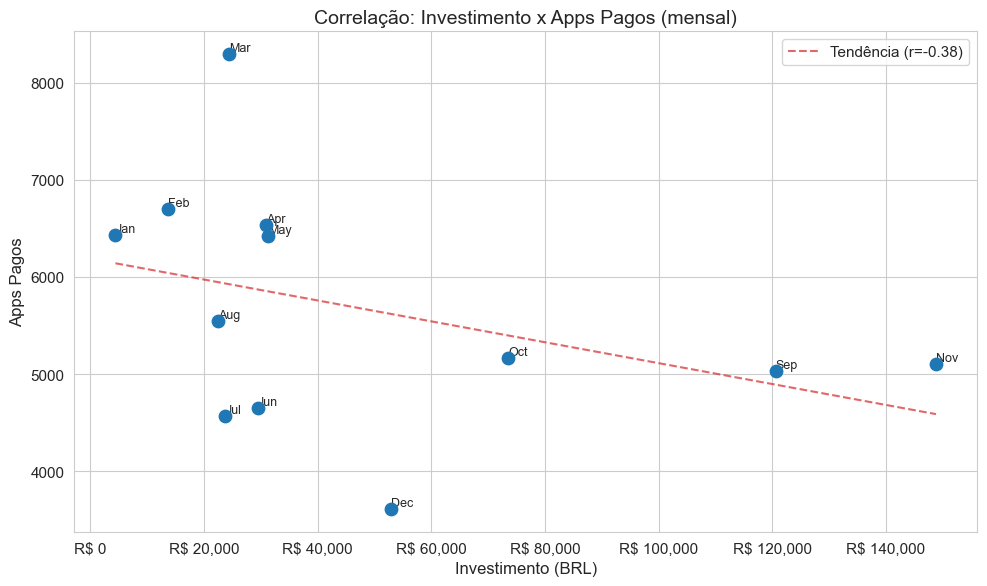

In [29]:
# Objetivo: Testar correlação mensal entre investimento e apps pagos na etapa 11.1.
# Leitura prática: Quantifica direção, força e significância da associação para apoiar decisões de escala.

# Agregação mensal para avaliar relação entre investimento e resultado final.
corr_mes = df_pivot.groupby('mes').agg(
    investimento_brl=('investimento_brl', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
).reset_index()

# Cálculo de Pearson e Spearman para direção, força e significância.
pearson_r, pearson_p = stats.pearsonr(corr_mes['investimento_brl'], corr_mes['apps_pagos'])
spearman_r, spearman_p = stats.spearmanr(corr_mes['investimento_brl'], corr_mes['apps_pagos'])

print(f"Pearson:  r={pearson_r:.3f}, p-value={pearson_p:.4f}")
print(f"Spearman: r={spearman_r:.3f}, p-value={spearman_p:.4f}")
print(f"N = {len(corr_mes)} meses")
print("Nota: amostra pequena - interpretar coeficientes com cautela.")

# Scatter com linha de tendência
# Visual de apoio com dispersão mensal e tendência linear.
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_mes['investimento_brl'], corr_mes['apps_pagos'], s=80, zorder=5)

z = np.polyfit(corr_mes['investimento_brl'], corr_mes['apps_pagos'], 1)
p = np.poly1d(z)
x_line = np.linspace(corr_mes['investimento_brl'].min(), corr_mes['investimento_brl'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='tab:red', alpha=0.7, label=f'Tendência (r={pearson_r:.2f})')

# Anotar cada ponto com o nome do mês
nomes_meses = pd.to_datetime(corr_mes['mes'], format='%m').dt.strftime('%b')
for i, row in corr_mes.iterrows():
    ax.annotate(nomes_meses.iloc[i], (row['investimento_brl'], row['apps_pagos']),
                fontsize=9, ha='left', va='bottom')

ax.set_xlabel('Investimento (BRL)')
ax.set_ylabel('Apps Pagos')
ax.set_title('Correlação: Investimento x Apps Pagos (mensal)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.tight_layout()
plt.show()


### 11.2 Investimento x Custo por Lead (CPL)

**Hipótese testada (H0/H1):**
- `H0`: não existe correlação estatisticamente significativa entre investimento e CPL.
- `H1`: existe correlação estatisticamente significativa entre investimento e CPL.

**O que implica:** se o aumento de investimento vier acompanhado de alta de CPL, há pressão de custo. A gestão deve priorizar alocação por eficiência marginal e limites de CPL antes de ampliar orçamento.


Pearson:  r=0.989, p-value=0.0000
Spearman: r=0.944, p-value=0.0000
N = 12 meses
Nota: amostra pequena - interpretar coeficientes com cautela.


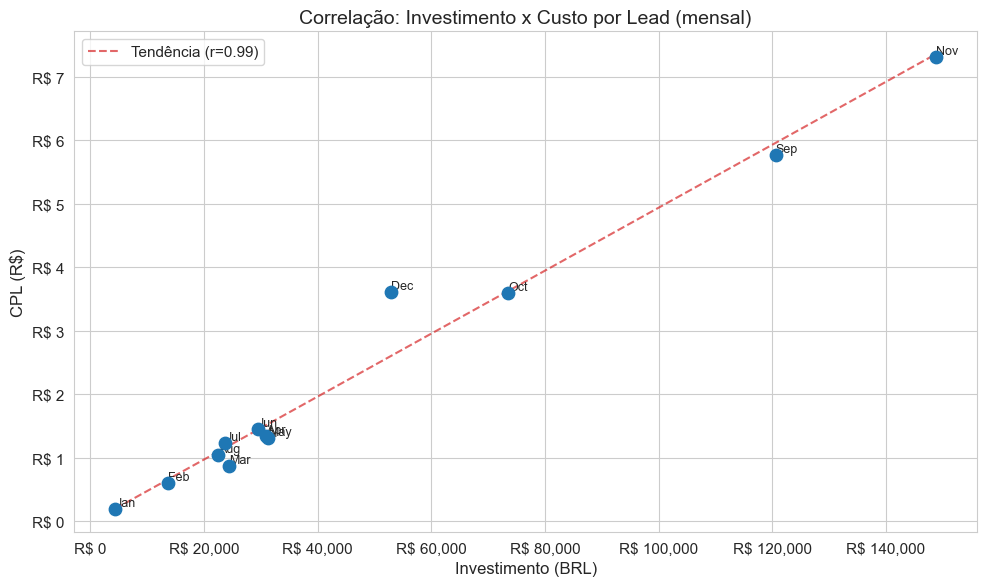

In [30]:
# Objetivo: Testar correlação mensal entre investimento e CPL na etapa 11.2.
# Leitura prática: Avalia se aumento de verba vem acompanhado de pressão de custo por lead.

# Agregar leads por mês e fazer merge (evita dependência de ordem)
# Derivação do CPL mensal a partir de investimento e volume de leads.
leads_mes = df_pivot.groupby('mes')['leads'].sum().reset_index()
corr_mes = corr_mes.merge(leads_mes, on='mes', how='left')
corr_mes['cpl'] = safe_div(corr_mes['investimento_brl'].values, corr_mes['leads'].values)

# Filtrar meses com investimento > 0
corr_cpl = corr_mes[corr_mes['investimento_brl'] > 0].copy()

# Cálculo de correlação para testar pressão de custo ao aumentar investimento.
pearson_r, pearson_p = stats.pearsonr(corr_cpl['investimento_brl'], corr_cpl['cpl'])
spearman_r, spearman_p = stats.spearmanr(corr_cpl['investimento_brl'], corr_cpl['cpl'])

print(f'Pearson:  r={pearson_r:.3f}, p-value={pearson_p:.4f}')
print(f'Spearman: r={spearman_r:.3f}, p-value={spearman_p:.4f}')
print(f'N = {len(corr_cpl)} meses')
print("Nota: amostra pequena - interpretar coeficientes com cautela.")

# Scatter com linha de tendência
# Visual de apoio da relação investimento versus CPL.
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_cpl['investimento_brl'], corr_cpl['cpl'], s=80, zorder=5)

z = np.polyfit(corr_cpl['investimento_brl'], corr_cpl['cpl'], 1)
p = np.poly1d(z)
x_line = np.linspace(corr_cpl['investimento_brl'].min(), corr_cpl['investimento_brl'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='tab:red', alpha=0.7, label=f'Tendência (r={pearson_r:.2f})')

nomes_meses = pd.to_datetime(corr_cpl['mes'], format='%m').dt.strftime('%b')
for i, (_, row) in enumerate(corr_cpl.iterrows()):
    ax.annotate(nomes_meses.iloc[i], (row['investimento_brl'], row['cpl']),
                fontsize=9, ha='left', va='bottom')

ax.set_xlabel('Investimento (BRL)')
ax.set_ylabel('CPL (R$)')
ax.set_title('Correlação: Investimento x Custo por Lead (mensal)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.tight_layout()
plt.show()


### 11.3 Conquistados: Search x Direto

**O que é efeito de halo:** é quando o desempenho de um canal influencia positivamente outro canal, mesmo sem investimento direto nesse segundo canal.

**Por que analisar isso aqui:** se Search gerar halo sobre Direto, parte do resultado de Direto pode vir de estímulo indireto de mídia. Isso muda a leitura de incrementalidade e a distribuição de verba.

**Hipótese testada (H0/H1):**
- `H0`: não existe correlação estatisticamente significativa entre conquistados de Search e de Direto.
- `H1`: existe correlação estatisticamente significativa entre conquistados de Search e de Direto.

**O que implica:** sem evidência robusta de halo, Search deve ser defendido principalmente por retorno direto. Com evidência robusta, o planejamento pode considerar também ganho indireto no canal Direto.


Pearson:  r=0.263, p-value=0.4085
Spearman: r=0.203, p-value=0.5273
N = 12 meses
Nota: amostra pequena - interpretar como indicio, nao como prova de causalidade.

Conquistados por Mes (Search vs Direto):

nome_mes  conquistados_search  conquistados_direto
     Jan                3,609                7,086
     Feb                2,291                8,325
     Mar                3,710                8,091
     Apr                2,943                5,810
     May                3,191                5,694
     Jun                2,411                4,609
     Jul                2,066                4,679
     Aug                3,399                4,586
     Sep                3,053                4,635
     Oct                2,967                4,976
     Nov                2,116                6,634
     Dec                2,287                3,492



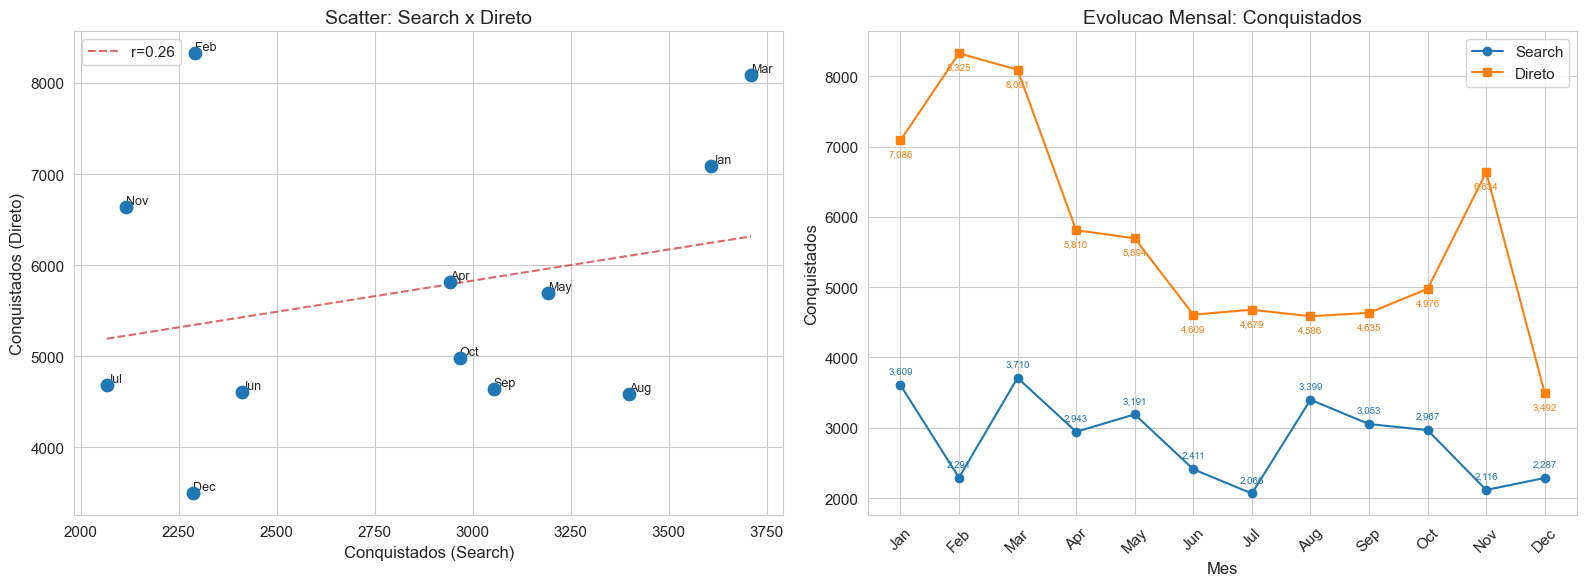

In [31]:
# Objetivo: Testar correlação entre Search e Direto no volume mensal de conquistados na etapa 11.3.
# Leitura prática: Apoia a leitura qualitativa sobre possível efeito de halo entre canais.

# Filtrar Search: tipo_campanha contém 'Search'
# Séries mensais de Search e Direto para testar possível efeito de halo.
df_search = df_pivot[df_pivot['tipo_campanha'].str.contains('Search', na=False)]
search_mes = df_search.groupby('mes')['conquistados'].sum().reset_index()
search_mes.columns = ['mes', 'conquistados_search']

# Filtrar Direto: canal == 'Direto'
df_direto = df_pivot[df_pivot['canal'] == 'Direto']
direto_mes = df_direto.groupby('mes')['conquistados'].sum().reset_index()
direto_mes.columns = ['mes', 'conquistados_direto']

# Merge
# Alinhamento mensal das duas séries para comparação estatística.
corr_sd = search_mes.merge(direto_mes, on='mes')

# Correlação linear e monotônica para leitura complementar da relação.
pearson_r, pearson_p = stats.pearsonr(corr_sd['conquistados_search'], corr_sd['conquistados_direto'])
spearman_r, spearman_p = stats.spearmanr(corr_sd['conquistados_search'], corr_sd['conquistados_direto'])

print(f"Pearson:  r={pearson_r:.3f}, p-value={pearson_p:.4f}")
print(f"Spearman: r={spearman_r:.3f}, p-value={spearman_p:.4f}")
print(f"N = {len(corr_sd)} meses")
print("Nota: amostra pequena - interpretar como indicio, nao como prova de causalidade.")

# Tabela numérica: conquistados por mês (Search vs Direto)
nomes_meses_corr = pd.to_datetime(corr_sd['mes'], format='%m').dt.strftime('%b')
tabela_conquistados = corr_sd.copy()
tabela_conquistados['nome_mes'] = nomes_meses_corr.values
tabela_conquistados = tabela_conquistados[['nome_mes', 'conquistados_search', 'conquistados_direto']]
print("\nConquistados por Mes (Search vs Direto):\n")
print(tabela_conquistados.to_string(index=False, float_format='{:,.0f}'.format))
print()

# Dois gráficos lado a lado: scatter + série temporal
# Dois visuais complementares: associação e comportamento ao longo do tempo.
fig, (eixo_scatter, eixo_temporal) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter com tendência
eixo_scatter.scatter(corr_sd['conquistados_search'], corr_sd['conquistados_direto'], s=80, zorder=5)
z = np.polyfit(corr_sd['conquistados_search'], corr_sd['conquistados_direto'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(corr_sd['conquistados_search'].min(), corr_sd['conquistados_search'].max(), 100)
eixo_scatter.plot(x_line, p_fit(x_line), '--', color='tab:red', alpha=0.7, label=f'r={pearson_r:.2f}')

nomes = pd.to_datetime(corr_sd['mes'], format='%m').dt.strftime('%b')
for i, linha in corr_sd.iterrows():
    eixo_scatter.annotate(nomes.iloc[i], (linha['conquistados_search'], linha['conquistados_direto']),
                fontsize=9, ha='left', va='bottom')
eixo_scatter.set_xlabel('Conquistados (Search)')
eixo_scatter.set_ylabel('Conquistados (Direto)')
eixo_scatter.set_title('Scatter: Search x Direto')
eixo_scatter.legend()

# Série temporal com anotações de valor
valores_search = corr_sd['conquistados_search'].values
valores_direto = corr_sd['conquistados_direto'].values

eixo_temporal.plot(nomes, valores_search, marker='o', label='Search')
eixo_temporal.plot(nomes, valores_direto, marker='s', label='Direto')

# Anotações de valor nos pontos
for indice_ponto in range(len(nomes)):
    eixo_temporal.annotate(f'{valores_search[indice_ponto]:,.0f}',
                          (nomes.iloc[indice_ponto], valores_search[indice_ponto]),
                          textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7, color='tab:blue')
    eixo_temporal.annotate(f'{valores_direto[indice_ponto]:,.0f}',
                          (nomes.iloc[indice_ponto], valores_direto[indice_ponto]),
                          textcoords='offset points', xytext=(0, -12), ha='center', fontsize=7, color='tab:orange')

eixo_temporal.set_title('Evolucao Mensal: Conquistados')
eixo_temporal.set_xlabel('Mes')
eixo_temporal.set_ylabel('Conquistados')
eixo_temporal.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### 11.4 Robustez a Outliers (identificar, tratar e comparar)

**Hipótese testada (H0/H1):**
- `H0`: as conclusões de correlação permanecem estáveis após tratamento de outliers.
- `H1`: as conclusões mudam de forma relevante após tratamento de outliers.

**O que implica:** antes de transformar correlação em decisão de negócio, é necessário validar sensibilidade a meses extremos. Nesta etapa, comparamos `Original`, `Tratado` (winsorização por IQR) e `Sem outliers`.

**Como interpretar Pearson e Spearman nesta etapa**

Usei `Pearson` e `Spearman` em conjunto para testar a consistência dos resultados.

- `Pearson` mede relação linear entre as variáveis e é mais sensível a valores extremos.
- `Spearman` mede relação monotônica por ranking e é mais robusto a outliers.

A leitura conjunta segue três critérios:
1. **Direção** da relação: sinal positivo ou negativo de `r`.
2. **Intensidade** da associação: magnitude de `r` (quanto mais próximo de `1` ou `-1`, mais forte).
3. **Significância estatística**: `p < 0,05` indica evidência estatística da associação.

In [32]:
# Objetivo: Definir funções auxiliares da etapa 11.4 para outliers, correlação e robustez.
# Leitura prática: Padroniza o método de comparação entre cenários original, tratado e sem outliers.

# 11.4 - Verificação de robustez a outliers nas correlações da etapa 11


# Critério IQR clássico para identificar limites de outliers por variável.
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


# Estatísticas de correlação por cenário com controle de tamanho amostral.
def calc_corr_stats(df, x_col, y_col):
    n = len(df)
    if n < 3:
        return {
            'pearson_r': np.nan, 'pearson_p': np.nan,
            'spearman_r': np.nan, 'spearman_p': np.nan,
            'N (meses)': n
        }

    pearson_r, pearson_p = stats.pearsonr(df[x_col], df[y_col])
    spearman_r, spearman_p = stats.spearmanr(df[x_col], df[y_col])

    return {
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'N': n
    }


# Regra de robustez: sinal e significância devem permanecer consistentes.
def robustez_relacao(stats_base, stats_treated, stats_clean, alpha=0.05):
    sign_ok_pearson = np.sign(stats_base['pearson_r']) == np.sign(stats_treated['pearson_r']) == np.sign(stats_clean['pearson_r'])
    sign_ok_spearman = np.sign(stats_base['spearman_r']) == np.sign(stats_treated['spearman_r']) == np.sign(stats_clean['spearman_r'])

    sig_base_p = stats_base['pearson_p'] < alpha if pd.notna(stats_base['pearson_p']) else None
    sig_treat_p = stats_treated['pearson_p'] < alpha if pd.notna(stats_treated['pearson_p']) else None
    sig_clean_p = stats_clean['pearson_p'] < alpha if pd.notna(stats_clean['pearson_p']) else None

    sig_base_s = stats_base['spearman_p'] < alpha if pd.notna(stats_base['spearman_p']) else None
    sig_treat_s = stats_treated['spearman_p'] < alpha if pd.notna(stats_treated['spearman_p']) else None
    sig_clean_s = stats_clean['spearman_p'] < alpha if pd.notna(stats_clean['spearman_p']) else None

    sig_ok_pearson = (sig_base_p == sig_treat_p == sig_clean_p)
    sig_ok_spearman = (sig_base_s == sig_treat_s == sig_clean_s)

    return 'Estável' if (sign_ok_pearson and sign_ok_spearman and sig_ok_pearson and sig_ok_spearman) else 'Sensível'


# Função utilitária para exibir meses extremos em formato legível.
def meses_label(meses):
    return ', '.join(map(str, meses)) if meses else 'nenhum'


# Visual de robustez: boxplots com destaque dos pontos extremos por relação.
def plot_boxplots_relacao(df_rel, x_col, y_col, x_label, y_label, relacao, meses_outliers, robustez):
    d = df_rel.copy()
    d['mes'] = d['mes'].astype(int)

    x_low, x_high = iqr_bounds(d[x_col])
    y_low, y_high = iqr_bounds(d[y_col])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    specs = [
        (x_col, x_label, (x_low, x_high)),
        (y_col, y_label, (y_low, y_high)),
    ]

    for ax, (col, label, bounds) in zip(axes, specs):
        # Outlier por variável individual (fora dos limites IQR desta variável)
        is_outlier = ~d[col].between(bounds[0], bounds[1])

        base = pd.DataFrame({
            'categoria': [label] * len(d),
            'valor': d[col].values,
            'mes': d['mes'].values,
            'outlier': is_outlier.values,
        })

        sns.boxplot(
            data=base,
            x='categoria', y='valor',
            ax=ax,
            color='#dbe5f1',
            width=0.42,
            fliersize=0,
            linewidth=1.2,
        )

        sns.stripplot(
            data=base[~base['outlier']],
            x='categoria', y='valor',
            ax=ax,
            color='#1f2937',
            size=5,
            alpha=0.78,
            jitter=0.12,
        )

        if base['outlier'].any():
            sns.stripplot(
                data=base[base['outlier']],
                x='categoria', y='valor',
                ax=ax,
                color='#c62828',
                size=7,
                alpha=0.95,
                jitter=0.07,
            )

            for _, row in base[base['outlier']].iterrows():
                ax.annotate(
                    f"M{int(row['mes'])}",
                    (0, row['valor']),
                    xytext=(6, 2),
                    textcoords='offset points',
                    fontsize=8,
                    color='#c62828',
                )

        ax.axhline(bounds[0], linestyle='--', linewidth=0.9, color='#7d8597', alpha=0.65)
        ax.axhline(bounds[1], linestyle='--', linewidth=0.9, color='#7d8597', alpha=0.65)
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.grid(axis='y', alpha=0.22)

    axes[0].set_ylabel('Valor')
    axes[1].set_ylabel('')

    fig.suptitle(
        f"{relacao} | outliers: {meses_label(meses_outliers)} | robustez: {robustez}",
        fontsize=11,
        fontweight='bold',
    )
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


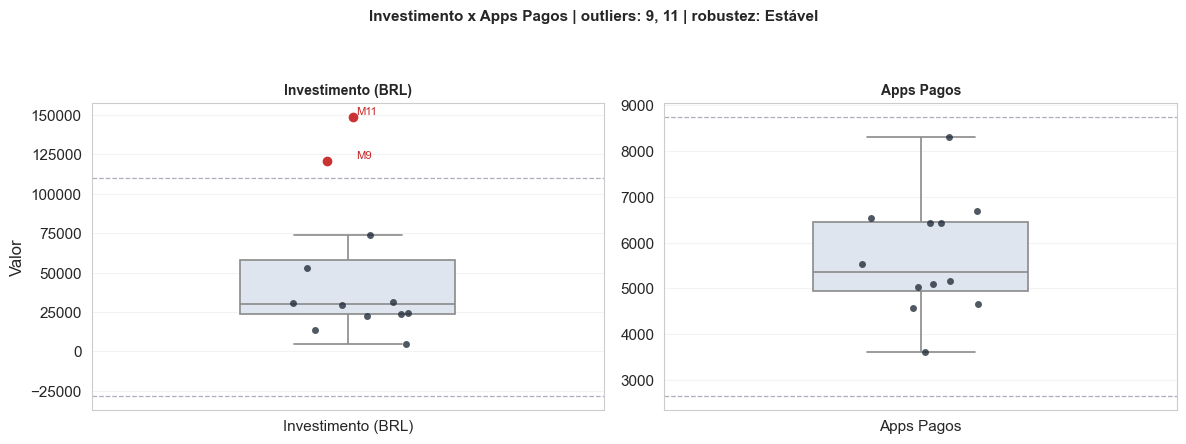

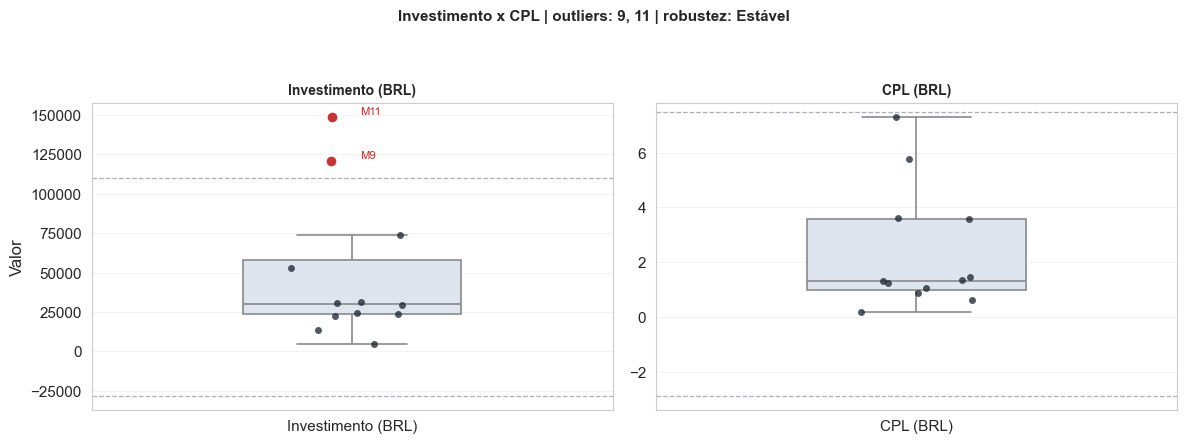

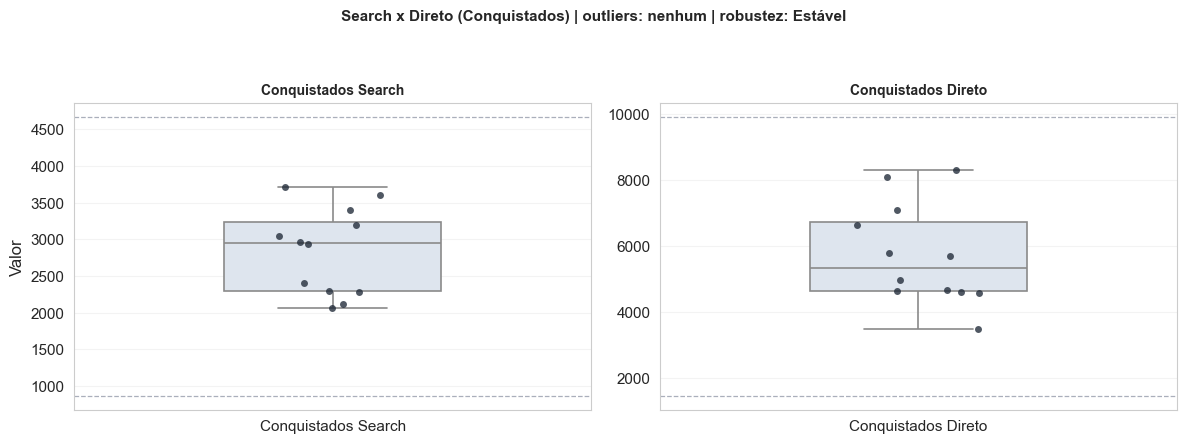

Resumo de outliers por relação:
                       Relacão Meses_outliers  Qtd_outliers Robustez
     Investimento x Apps Pagos          9, 11             2  Estável
            Investimento x CPL          9, 11             2  Estável
Search x Direto (Conquistados)         nenhum             0  Estável

Comparativo de correlações por cenário:
                       Relacão      Cenário  N (meses)  Pearson_r  Pearson_p  Spearman_r  Spearman_p
     Investimento x Apps Pagos     Original         12    -0.3825     0.2197     -0.4336      0.1591
     Investimento x Apps Pagos      Tratado         12    -0.4206     0.1734     -0.4378      0.1546
     Investimento x Apps Pagos Sem outliers         10    -0.4646     0.1761     -0.4061      0.2443
            Investimento x CPL     Original         12     0.9887     0.0000      0.9441      0.0000
            Investimento x CPL      Tratado         12     0.9784     0.0000      0.9422      0.0000
            Investimento x CPL Sem outliers  

In [33]:
# Objetivo: Executar a análise de robustez da etapa 11.4 para cada relação de correlação.
# Leitura prática: Entrega meses extremos, comparação por cenário e status final de estabilidade.

# Relações avaliadas na etapa 11.4, reutilizando bases já calculadas.
analises_outlier = [
    {
        'relação': 'Investimento x Apps Pagos',
        'df': corr_mes[['mes', 'investimento_brl', 'apps_pagos']].copy(),
        'x': 'investimento_brl',
        'y': 'apps_pagos',
        'x_label': 'Investimento (BRL)',
        'y_label': 'Apps Pagos',
    },
    {
        'relação': 'Investimento x CPL',
        'df': corr_cpl[['mes', 'investimento_brl', 'cpl']].copy(),
        'x': 'investimento_brl',
        'y': 'cpl',
        'x_label': 'Investimento (BRL)',
        'y_label': 'CPL (BRL)',
    },
    {
        'relação': 'Search x Direto (Conquistados)',
        'df': corr_sd[['mes', 'conquistados_search', 'conquistados_direto']].copy(),
        'x': 'conquistados_search',
        'y': 'conquistados_direto',
        'x_label': 'Conquistados Search',
        'y_label': 'Conquistados Direto',
    },
]

rows_corr = []
rows_outlier = []

# Pipeline por relação: identificar outliers, gerar cenários e medir robustez.
for item in analises_outlier:
    rel = item['relação']
    dfr = item['df'].copy()
    x_col = item['x']
    y_col = item['y']

    x_low, x_high = iqr_bounds(dfr[x_col])
    y_low, y_high = iqr_bounds(dfr[y_col])

# Regra de outlier: mês é extremo quando x ou y está fora do limite IQR.
    out_mask = (~dfr[x_col].between(x_low, x_high)) | (~dfr[y_col].between(y_low, y_high))
    meses_outliers = sorted(dfr.loc[out_mask, 'mes'].astype(int).tolist())

    df_original = dfr.copy()

# Cenário tratado: winsorização por clipping nos limites IQR.
    df_tratado = dfr.copy()
    df_tratado[x_col] = df_tratado[x_col].clip(x_low, x_high)
    df_tratado[y_col] = df_tratado[y_col].clip(y_low, y_high)

# Cenário alternativo: remoção dos meses extremos para sensibilidade.
    df_sem_outliers = dfr.loc[~out_mask].copy()

    st_original = calc_corr_stats(df_original, x_col, y_col)
    st_tratado = calc_corr_stats(df_tratado, x_col, y_col)
    st_sem_out = calc_corr_stats(df_sem_outliers, x_col, y_col)

    robustez = robustez_relacao(st_original, st_tratado, st_sem_out, alpha=0.05)

    for cenario, st in [('Original', st_original), ('Tratado', st_tratado), ('Sem outliers', st_sem_out)]:
        rows_corr.append({
            'Relacão': rel,
            'Cenário': cenario,
            'N (meses)': st['N'],
            'Pearson_r': st['pearson_r'],
            'Pearson_p': st['pearson_p'],
            'Spearman_r': st['spearman_r'],
            'Spearman_p': st['spearman_p']
        })

    rows_outlier.append({
        'Relacão': rel,
        'Meses_outliers': meses_label(meses_outliers),
        'Qtd_outliers': len(meses_outliers),
        'Robustez': robustez
    })

    # Figura enxuta por relação
    plot_boxplots_relacao(
        dfr,
        x_col=x_col,
        y_col=y_col,
        x_label=item['x_label'],
        y_label=item['y_label'],
        relacao=rel,
        meses_outliers=meses_outliers,
        robustez=robustez,
    )

# Consolidação final das saídas tabulares da etapa 11.4.
outliers_11_4 = pd.DataFrame(rows_outlier)
corr_robustez_11_4 = pd.DataFrame(rows_corr)

print('Resumo de outliers por relação:')
print(outliers_11_4.to_string(index=False))

print('')
print('Comparativo de correlações por cenário:')
print(
    corr_robustez_11_4.to_string(
        index=False,
        float_format=lambda x: f'{x:.4f}'
    )
)


---
## 12. Análises Extras

Análises complementares de eficiência e alocação para enriquecer as recomendações.

### 12.1 Eficiência de Verba: Pareto do Investimento

Pareto: Share de Investimento vs Share de Apps Pagos:

                canal  investimento_brl  participacao_investimento  apps_pagos  participacao_apps
           Google Ads        363,376.92                      63.06   20,090.00              90.13
                Weach        196,483.08                      34.10    1,037.00               4.65
            Afiliados         13,915.52                       2.41      113.00               0.51
Microsoft Advertising          2,412.10                       0.42      751.00               3.37
             Referral             43.73                       0.01      300.00               1.35



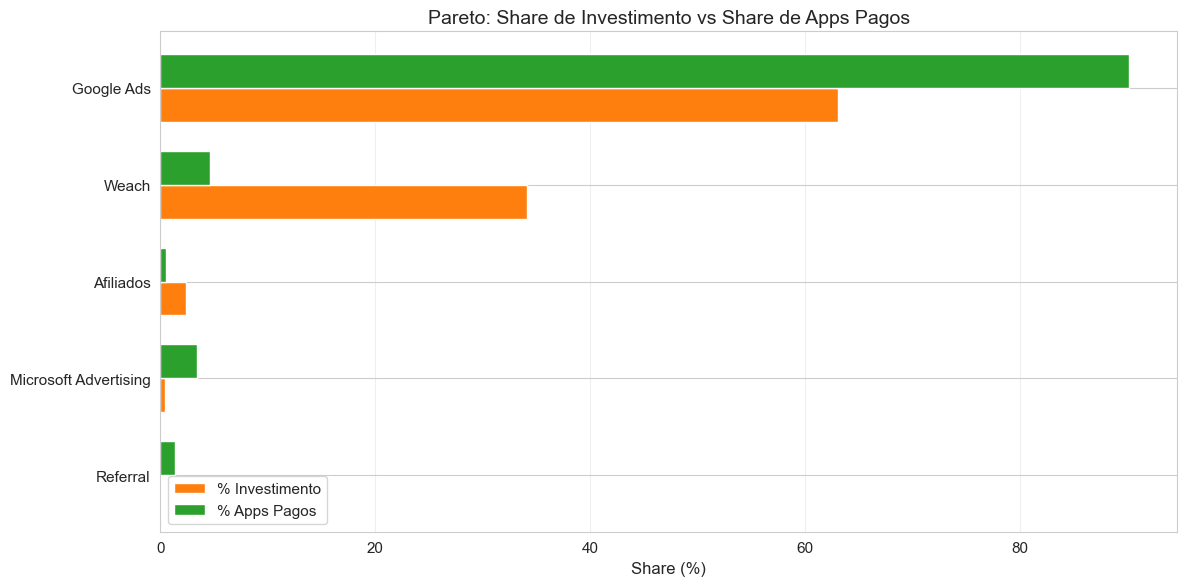

In [34]:
# Objetivo: Montar a leitura de Pareto entre participação de investimento e participação de apps pagos.
# Leitura prática: Mostra desequilíbrios de eficiência para direcionar realocação entre canais.

# Base de Pareto: canais com investimento positivo para comparação de share.
pareto = canal_agg[canal_agg['investimento_brl'] > 0][['canal', 'investimento_brl', 'apps_pagos']].copy()
pareto['participacao_investimento'] = pareto['investimento_brl'] / pareto['investimento_brl'].sum() * 100
pareto['participacao_apps'] = pareto['apps_pagos'] / pareto['apps_pagos'].sum() * 100
pareto = pareto.sort_values('participacao_investimento', ascending=True)

# Tabela numérica
tabela_pareto = pareto[['canal', 'investimento_brl', 'participacao_investimento', 'apps_pagos', 'participacao_apps']].sort_values('participacao_investimento', ascending=False)
print("Pareto: Share de Investimento vs Share de Apps Pagos:\n")
print(tabela_pareto.to_string(index=False, float_format='{:,.2f}'.format))
print()

# Visual horizontal para contraste entre participação de investimento e retorno.
fig, ax = plt.subplots(figsize=(12, 6))
posicao_y = range(len(pareto))
largura = 0.35

ax.barh([y - largura/2 for y in posicao_y], pareto['participacao_investimento'].values,
        largura, label='% Investimento', color='tab:orange')
ax.barh([y + largura/2 for y in posicao_y], pareto['participacao_apps'].values,
        largura, label='% Apps Pagos', color='tab:green')

ax.set_yticks(list(posicao_y))
ax.set_yticklabels(pareto['canal'].values)
ax.set_xlabel('Share (%)')
ax.set_title('Pareto: Share de Investimento vs Share de Apps Pagos')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### 12.2 CPA por Canal

**O que está sendo feito:**
- Cálculo do CPA (Custo por Aquisição) por canal para identificar os canais mais eficientes na conversão final.

**Por que isso importa:**
- O CPA por canal orienta a realocação de verba para canais com menor custo de conversão.

CPA por Canal (canais com investimento e apps > 0):

                canal    cpa
             Referral   0.15
Microsoft Advertising   3.21
           Google Ads  18.09
            Afiliados 123.15
                Weach 189.47



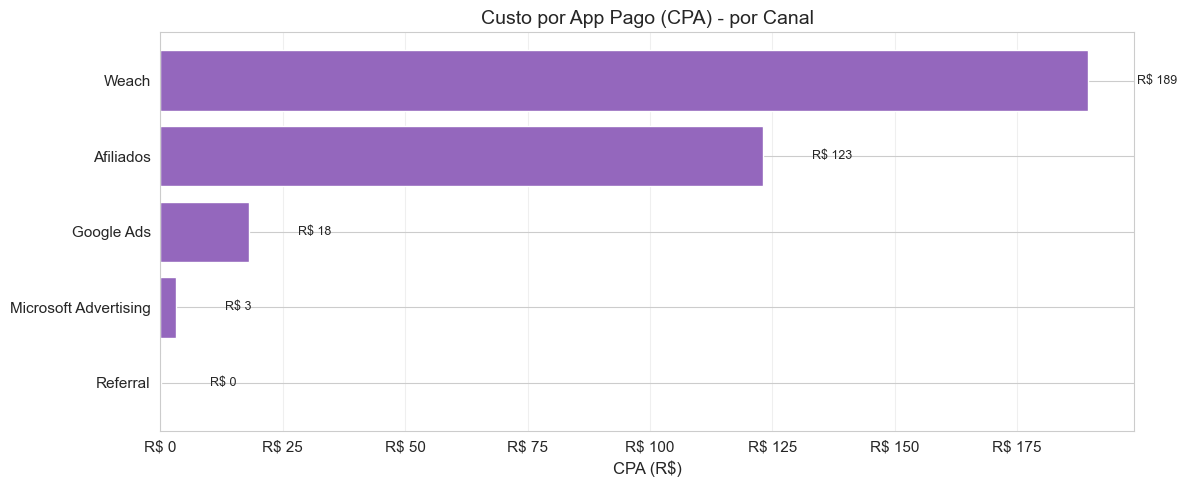

In [35]:
# Objetivo: Comparar CPA por canal com investimento e conversão válidos.
# Leitura prática: Evidencia quais canais entregam app pago com menor custo unitário.

# Menor CPA = canal mais eficiente na conversão final

# Recorte analítico: somente canais com investimento e apps pagos maiores que zero.
cpa_canal = canal_agg[
    (canal_agg['investimento_brl'] > 0) & (canal_agg['apps_pagos'] > 0)
][['canal', 'cpa']].sort_values('cpa', ascending=True)

# Tabela numérica
print("CPA por Canal (canais com investimento e apps > 0):\n")
print(cpa_canal.to_string(index=False, float_format='{:,.2f}'.format))
print()

# Visual de ranking para leitura rápida do custo por app pago.
fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.barh(cpa_canal['canal'], cpa_canal['cpa'], color='tab:purple')
ax.set_xlabel('CPA (R$)')
ax.set_title('Custo por App Pago (CPA) - por Canal')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.grid(True, alpha=0.3, axis='x')

# Anotar valores nas barras
for indice, (_, linha) in enumerate(cpa_canal.iterrows()):
    ax.text(linha['cpa'] + 10, indice, f"R$ {linha['cpa']:,.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 12.3 Evolução do Investimento e ROI ao longo do Ano

**O que está sendo feito:** Visualização da tendência mensal de investimento, apps pagos, CPA e CPL.

**Por que isso importa:** Mostra se a eficiência de custo melhorou ou piorou ao longo do ano, orientando timing de investimento.


Evolução Mensal:

nome_mes  investimento_brl  apps_pagos     leads   cpa  cpl
     Jan          4,405.51    6,431.00 22,801.00  0.69 0.19
     Feb         13,613.07    6,696.00 22,447.00  2.03 0.61
     Mar         24,358.95    8,294.00 28,122.00  2.94 0.87
     Apr         30,890.82    6,535.00 23,018.00  4.73 1.34
     May         31,257.34    6,425.00 23,957.00  4.86 1.30
     Jun         29,464.02    4,652.00 20,220.00  6.33 1.46
     Jul         23,760.86    4,568.00 19,433.00  5.20 1.22
     Aug         22,540.84    5,541.00 21,717.00  4.07 1.04
     Sep        120,618.33    5,028.00 20,941.00 23.99 5.76
     Oct         73,555.41    5,166.00 20,509.00 14.24 3.59
     Nov        148,810.31    5,106.00 20,365.00 29.14 7.31
     Dec         52,955.89    3,613.00 14,686.00 14.66 3.61



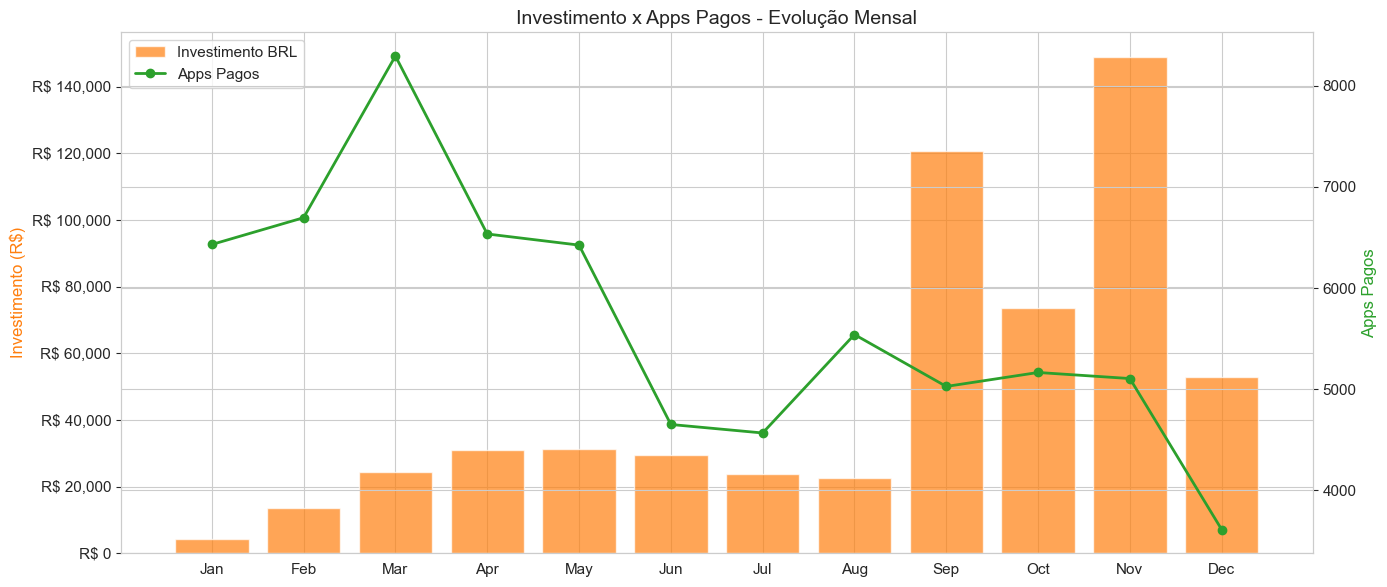

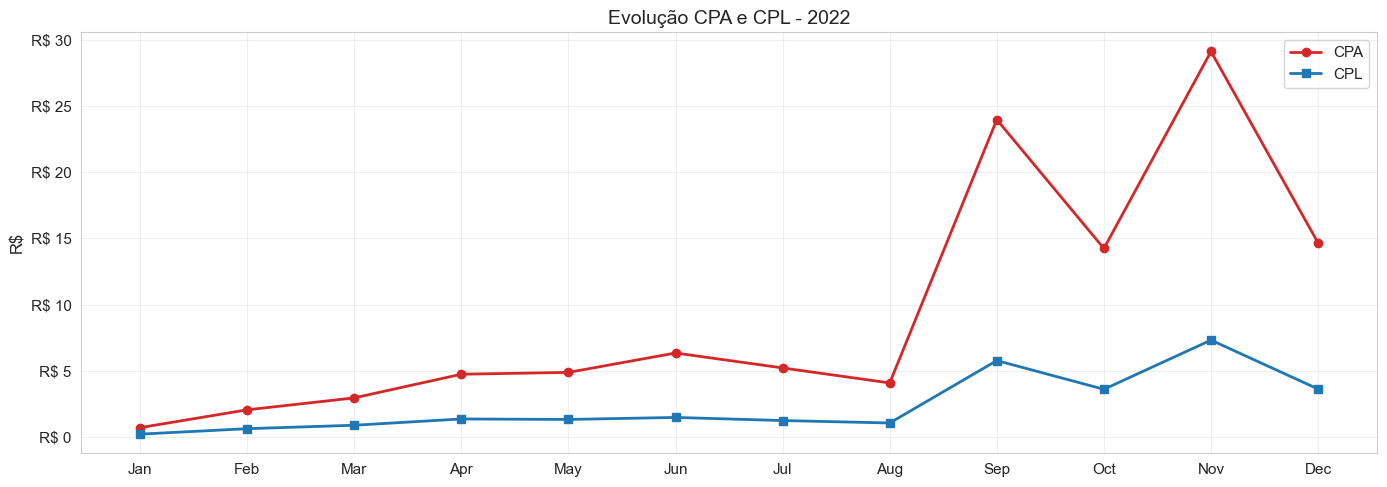

In [36]:
# Objetivo: Analisar evolução mensal de investimento, volume e eficiência ao longo do ano.
# Leitura prática: Conecta sazonalidade operacional com variações de CPA e CPL no período.

# Consolidação mensal de volume e investimento para leitura temporal.
evolucao_mensal = df_pivot.groupby('mes').agg(
    investimento_brl=('investimento_brl', 'sum'),
    apps_pagos=('apps_pagos', 'sum'),
    leads=('leads', 'sum'),
).reset_index()

# Métricas derivadas de eficiência para comparar custo ao longo dos meses.
evolucao_mensal['cpa'] = safe_div(evolucao_mensal['investimento_brl'].values, evolucao_mensal['apps_pagos'].values)
evolucao_mensal['cpl'] = safe_div(evolucao_mensal['investimento_brl'].values, evolucao_mensal['leads'].values)
nomes_meses = pd.to_datetime(evolucao_mensal['mes'], format='%m').dt.strftime('%b')

# Tabela numérica
tabela_evolucao = evolucao_mensal.copy()
tabela_evolucao['nome_mes'] = nomes_meses
colunas_exibicao = ['nome_mes', 'investimento_brl', 'apps_pagos', 'leads', 'cpa', 'cpl']
print("Evolução Mensal:\n")
print(tabela_evolucao[colunas_exibicao].to_string(index=False, float_format='{:,.2f}'.format))
print()

# Gráfico 1: Investimento (barras) + Apps Pagos (linha)
# Gráfico 1: evolução mensal de investimento versus apps pagos.
fig, eixo_principal = plt.subplots(figsize=(14, 6))
eixo_principal.bar(nomes_meses, evolucao_mensal['investimento_brl'], color='tab:orange', alpha=0.7, label='Investimento BRL')
eixo_principal.set_ylabel('Investimento (R$)', color='tab:orange')
eixo_principal.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

eixo_secundario = eixo_principal.twinx()
eixo_secundario.plot(nomes_meses, evolucao_mensal['apps_pagos'], color='tab:green', marker='o', linewidth=2, label='Apps Pagos')
eixo_secundario.set_ylabel('Apps Pagos', color='tab:green')

linhas1, rotulos1 = eixo_principal.get_legend_handles_labels()
linhas2, rotulos2 = eixo_secundario.get_legend_handles_labels()
eixo_principal.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc='upper left')
eixo_principal.set_title('Investimento x Apps Pagos - Evolução Mensal')
plt.tight_layout()
plt.show()

# Gráfico 2: CPA e CPL mensais - tendência de eficiência
# Gráfico 2: evolução mensal de CPA e CPL para leitura de eficiência.
fig, eixo = plt.subplots(figsize=(14, 5))
eixo.plot(nomes_meses, evolucao_mensal['cpa'], marker='o', linewidth=2, label='CPA', color='tab:red')
eixo.plot(nomes_meses, evolucao_mensal['cpl'], marker='s', linewidth=2, label='CPL', color='tab:blue')
eixo.set_ylabel('R$')
eixo.set_title('Evolução CPA e CPL - 2022')
eixo.legend()
eixo.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
eixo.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 13. Números Chave

**O que está sendo feito:**
- Consolidação dos principais indicadores globais de volume, conversão e custo.

**Por que isso importa:**
- Entrega visão objetiva para comunicação executiva e comparação rápida de cenário.


In [ ]:
# Objetivo: Consolidar os indicadores finais de funil, finanças, eficiência e proxy executivo de meta.
# Leitura prática: Resume os números âncora usados no fechamento técnico e executivo do case.

# Consolidação dos principais indicadores para visão rápida dos resultados

# Soma anual das métricas base para fechamento consolidado do case.
totais = df_pivot[metricas_funil + ['investimento_brl', 'faturamento']].sum()

print('=' * 60)
print('RESUMO EXECUTIVO - 2022')
print('=' * 60)

print(f"\nFUNIL DE AQUISIÇÃO:")
for i, (metrica, label) in enumerate(zip(metricas_funil, labels_funil)):
    valor = totais[metrica]
    print(f"  {label:<20s}: {valor:>10,.0f}")
    if i > 0:
        anterior = totais[metricas_funil[i-1]]
        taxa = valor / anterior * 100 if anterior > 0 else 0
        print(f"    {'CVR':<18s}: {taxa:>9.1f}%")

# Bloco 2: derivação de indicadores financeiros e de eficiência.
leads_total = totais['leads']
apps_total = totais['apps_pagos']
inv_total = totais['investimento_brl']
faturamento_total = totais['faturamento']

cpl_geral = inv_total / leads_total if leads_total > 0 else 0
cpa_geral = inv_total / apps_total if apps_total > 0 else 0

# Bloco 3: proxy executivo para traduzir a meta de NMRR em apps adicionais.
ticket_proxy_app = faturamento_total / apps_total if apps_total > 0 else 0
incremento_receita_meta = faturamento_total * 0.10
apps_adicionais_proxy = incremento_receita_meta / ticket_proxy_app if ticket_proxy_app > 0 else 0

print(f"\nFINANCEIRO:")
print(f"  {'Investimento BRL':<20s}: R$ {inv_total:>12,.2f}")
print(f"  {'Faturamento':<20s}: R$ {faturamento_total:>12,.2f}")

print(f"\nEFICIÊNCIA:")
print(f"  {'CPL geral':<20s}: R$ {cpl_geral:>10,.2f}")
print(f"  {'CPA geral':<20s}: R$ {cpa_geral:>10,.2f}")
print(f"  {'CVR Lead→App':<20s}: {(apps_total/leads_total*100) if leads_total > 0 else 0:.1f}%")

print(f"\nTRADUÇÃO EXECUTIVA DA META NMRR (PROXY):")
print(
    f"  ticket_proxy_app = faturamento_total / apps_total = "
    f"R$ {faturamento_total:,.0f} / {apps_total:,.0f} = R$ {ticket_proxy_app:,.2f}"
)
print(
    f"  incremento_receita_meta = faturamento_total * 10% = "
    f"R$ {faturamento_total:,.0f} * 10% = R$ {incremento_receita_meta:,.0f}"
)
print(
    f"  apps_adicionais_proxy = incremento_receita_meta / ticket_proxy_app = "
    f"R$ {incremento_receita_meta:,.0f} / R$ {ticket_proxy_app:,.2f} = {apps_adicionais_proxy:,.0f} apps"
)
print("  Observação: proxy executivo sob hipótese de ticket constante, sem inferência causal.")


RESUMO EXECUTIVO - 2022

FUNIL DE AQUISIÇÃO:
  Impressões          : 38,111,501
  Cliques             :    305,990
    CVR               :       0.8%
  Sessões             :  3,136,117
    CVR               :    1024.9%
  Formulários         :    711,848
    CVR               :      22.7%
  Leads               :    258,216
    CVR               :      36.3%
  Atribuídos          :    163,541
    CVR               :      63.3%
  Agendamentos        :    127,775
    CVR               :      78.1%
  Conquistados        :    120,557
    CVR               :      94.4%
  Apps Pagos          :     68,055
    CVR               :      56.5%

FINANCEIRO:
  Investimento BRL    : R$   576,231.35
  Faturamento         : R$ 33,192,000.00

EFICIÊNCIA:
  CPL geral           : R$       2.23
  CPA geral           : R$       8.47
  CVR Lead→App        : 26.4%

TRADUÇÃO EXECUTIVA DA META NMRR (PROXY):
  ticket_proxy_app = faturamento_total / apps_total = R$ 33,192,000 / 68,055 = R$ 487.72
  incremento_rec

## 14. Síntese Analítica

### 14.1 Cobertura do desafio

A tabela abaixo consolida as respostas para cada pergunta do case técnico, com base nos resultados obtidos nas análises das etapas anteriores.

| Pergunta do case | Achado principal | Base analítica |
| --- | --- | --- |
| Performance geral por canal e tipo de campanha | Direto gera `55%` dos leads (`140,6 mil` de `258,2 mil`) e `58%` dos apps pagos (`39,3 mil` de `68,1 mil`) sem investimento. Pago investe `R$576 mil` para `36%` dos leads, com CPA médio de `R$24,46`. | `7.1`, `7.2`, `7.3` |
| Funil por canal: impressões até apps pagos | Google Ads lidera topo de funil (`38,1 mi` impressões, `303,7 mil` cliques). Direto lidera meio e fundo (`89,6 mil` atribuídos, `39,3 mil` apps pagos). Gargalo crítico: `36,7%` dos leads (`94.675`) não chegam à atribuição comercial. | `8`, `13` |
| Leads por mês e sazonalidade | Pico em março (`28.122` leads), vale em dezembro (`14.686`). Faixa intermediária estável entre `22 mil` e `24 mil` leads. | `9` |
| Performance por tipo de campanha paga | Google Search Geral: melhor combinação escala-eficiência (CPA `R$2,53`, `8.580` apps). Google PMax: maior concentração de verba com menor retorno (CPA `R$350,41`, `974` apps). Diferença de `138x` entre extremos. | `10`, `12.1` |
| Investimento x apps pagos | Correlação fraca e não significativa (Pearson `r=-0,383`, `p=0,22`). Aumento de verba isolado não é alavanca de crescimento. | `11.1`, `11.4` |
| Investimento x CPL | Correlação forte e significativa (Pearson `r=0,989`, `p<0,001`). Escalar investimento esteve associado a aumento de custo por lead. | `11.2`, `11.4` |
| Correlação Search x Direto (efeito halo) | Sem evidência estatística de efeito halo (Pearson `r=0,263`, `p=0,41`). Search deve ser avaliado por resultado direto, não por premissa de influência indireta. | `11.3`, `11.4` |

### 14.2 Três insights críticos para decisão

Os três achados abaixo sintetizam as evidências com maior impacto sobre a estratégia de crescimento de NMRR.

| Insight | Evidência | Implicação para Growth | Base analítica |
| --- | --- | --- | --- |
| Ineficiência severa em mídia paga | CPA de PMax (`R$350,41`) e Weach (`R$189,47`) versus Search (`R$2,53`). Diferença de `138x` entre extremos. | Realocar verba para tipos eficientes gera mais apps por real investido, sem necessidade de ampliar orçamento total. | `10`, `12.1` |
| Gargalo de atribuição desperdiçando leads | `94.675` leads (`36,7%`) não chegam à atribuição comercial. A maior perda absoluta do funil ocorre antes da atuação do time de vendas. | Elevar cobertura de atribuição aumenta volume útil de leads para o comercial sem ampliar aquisição. | `8`, `13` |
| Escalar verba eleva CPL sem garantia de conversão | `r=0,989` entre investimento e CPL (significativo) versus `r=-0,383` entre investimento e apps pagos (não significativo). | Crescimento deve vir por eficiência e operação, não por aumento linear de orçamento. | `11.1`, `11.2` |

### 14.3 Roadmap analítico não executado

Estas frentes são mencionadas para explicitar o que ainda não foi medido no case e orientar o plano de evolução analítica do time. Na prática, elas ajudam Growth, Marketing, Vendas e Dados a priorizar estudos com maior impacto, definir pré condições de execução e reduzir risco de decisão com informação incompleta.

| Frente | Viabilidade | Como ajuda na decisão | Condição mínima |
| --- | --- | --- | --- |
| ROAS | Viável com dados atuais | Prioriza canais por retorno financeiro direto. | Consistência de faturamento e investimento por canal. |
| CAC padronizado | Viável com dados atuais | Compara eficiência de aquisição em base uniforme. | Definição formal do evento padrão de aquisição. |
| Modelagem preditiva | Viável com dados atuais | Simula cenários de metas e orçamento. | Uso exploratório com janela curta de `12` meses. |
| Cohort | Depende de dados adicionais/desenho experimental | Mede retenção e velocidade de conversão por safra. | `lead_id` ou `cliente_id` com linha do tempo por lead. |
| Teste A/B | Depende de dados adicionais/desenho experimental | Valida incrementalidade causal antes de escalar. | Randomização, grupo de controle e protocolo experimental. |
| Atribuição multi touch | Depende de dados adicionais/desenho experimental | Mede contribuição combinada dos canais na jornada. | Trilha de interações por usuário. |
| LTV e LTV vs CAC | Depende de dados adicionais/desenho experimental | Orienta crescimento por valor de longo prazo. | Histórico com retenção, receita recorrente e churn. |



## 15. Recomendações e Conclusão

A meta de `+10%` em NMRR até dezembro de 2023 com orçamento limitado exige foco em eficiência e ganho operacional do funil. Com ticket médio de `R$488` por app (informação embasada pela etapa `13`), o incremento representa aproximadamente `R$3,3 mi` adicionais, o que equivale a cerca de `6.800` apps pagos a mais no ano.

### Plano de ação

| Prioridade | Ação | Impacto esperado | Indicador de sucesso | Base analítica |
| --- | --- | --- | --- | --- |
| `1` | Realocar `20%` da verba de PMax e Weach para Search e Bing, em piloto de `4` a `6` semanas | Mais apps por real investido, com redução de CPA médio do bloco pago | Queda de CPA médio pago com manutenção ou aumento de volume de apps | `10`, `12.1`, `11.4` |
| `2` | Elevar cobertura de Lead para Atribuído acima de `63,3%`, com revisão mensal de SLA e critérios comerciais | Recuperar parcela dos `~95 mil` leads anuais que ficam fora da atribuição | Taxa de atribuição crescente mês a mês, acima de `63,3%` | `8`, `13` |
| `3` | Acelerar ativação de `~52 mil` conquistados em apps pagos, com checkpoints quinzenais | Converter maior parcela de conquistados na última etapa do funil | Taxa de conquistados para apps acima de `56,5%` | `13` |

### Riscos e condições de execução

1. **Teto de CPL:** escala de investimento deve respeitar limite de custo por lead, dado que a relação investimento-CPL é forte e positiva (etapa `11.2`).
2. **Cautela causal:** investimento e apps pagos não apresentaram significância estatística (etapa `11.1`). Decisões de escala devem ser baseadas em eficiência, não em premissa de correlação.
3. **Governança de dados:** `32,7%` de registros órfãos na base bruta (etapas `3.1`, `4.4`) e nomenclatura heterogênea no canal Direto (etapa `6`) exigem padronização contínua para manter confiabilidade de mensuração.

### Encerramento executivo

A análise demonstra que o caminho para `+10%` em NMRR passa por três frentes complementares: 
1. Eficiência de mídia paga; 
2. Cobertura de atribuição 
3. Ativação de conquistados. 

Com a aprovação do piloto de realocação de verba, do plano de cobertura comercial e da rotina de ativação, a empresa estabelece uma rota de crescimento com disciplina de investimento e controle de risco analítico.
